# **IMPORT LIBRARIES**

In [ ]:
from google.colab import drive

drive.mount('/content/drive')

In [ ]:
!pip install -U transformers
!pip install qwen-vl-utils

In [ ]:
import pandas as pd
import numpy as np


import seaborn as sns
import matplotlib.pyplot as plt
from itertools import combinations
from collections import defaultdict

import os
import zipfile

import json
import re

import torch
from transformers import (
    Qwen2VLForConditionalGeneration,
    AutoProcessor,
    TrainingArguments,
    Trainer,
    AutoModelForVision2Seq,
    TrainerCallback,
    Blip2ForConditionalGeneration,
    Blip2Processor
)
from peft import LoraConfig, get_peft_model
from qwen_vl_utils import process_vision_info

import csv
from peft import PeftModel


# **DATA EXPLORATION**

A comprehensive analysis of categorical columns.

Three main stages:
1. **Data Preprocessing & Normalization**: The workflow begins by cleaning columns that contain stringified lists (e.g., "['A', 'B']"). It converts them into standardized, flat comma-separated strings.

2. **Analysis (Univariate)**: It calculates the frequency of every individual term across the selected columns. A custom dashboard is generated for each category, visualizing:
    *   The Top 15 most frequent items.
    *   The cardinality distribution (how many items typically appear in a single row).
    * Global statistics and frequency tiers (identifying rare vs. common terms).

3. **Co-occurrence Analysis (Multivariate)**: The script analyzes the relationships between terms by calculating co-occurrences (how often two terms appear together in the same entry). It outputs a ranked list of the strongest pairs and visualizes these relationships using a heatmap.

In [ ]:
def normalize_list_column(value):
    """
    Convert "['item1', 'item2']" in "item1, item2"
    """
    if pd.isna(value) or value == '[]' or value == '':
        return ''

    cleaned = str(value).replace('[', '').replace(']', '').replace("'", "").replace('"', '')

    items = [item.strip() for item in cleaned.split(',') if item.strip()]

    return ', '.join(items)

In [ ]:
def crea_dashboard_distribuzione(dizionario, nome_colonna, df, top_n=10):

    fig = plt.figure(figsize=(10, 14), dpi=150)

    gs = fig.add_gridspec(3, 2, hspace=0.3, wspace=0.3, height_ratios=[1, 1, 0.8])

    # ====================
    ax1 = fig.add_subplot(gs[0, :])
    items_ordinati = sorted(dizionario.items(), key=lambda x: x[1], reverse=True)
    top_items = items_ordinati[:top_n]
    labels = [item[0][:30] for item in top_items]
    counts = [item[1] for item in top_items]
    totale = sum(dizionario.values())
    percentuali = [(c/totale)*100 for c in counts]

    bars = ax1.barh(range(len(labels)), counts, color='#ef476fff')
    for spine in ax1.spines.values():
        spine.set_visible(False)

    ax1.set_xticks([])
    ax1.set_xlabel('')
    ax1.tick_params(axis='both', which='both', left=False, bottom=False)

    ax1.set_yticks(range(len(labels)))
    ax1.set_yticklabels(labels, fontsize=8)

    ax1.set_xlabel('Frequency')
    ax1.set_title(f'Top {top_n} elements')
    ax1.invert_yaxis()

    for i, (count, perc) in enumerate(zip(counts, percentuali)):
        ax1.text(count, i, f' {perc:.1f}%', va='center', fontsize=7, fontweight='bold')

    # ====================
    ax2 = fig.add_subplot(gs[1, 0])

    conteggi_per_riga = []
    for valore in df[nome_colonna].dropna():
        if isinstance(valore, str) and valore.strip():
            n_elementi = len([x.strip() for x in valore.split(',') if x.strip()])
            conteggi_per_riga.append(n_elementi)

    max_elementi = max(conteggi_per_riga) if conteggi_per_riga else 1
    fasce_elementi = list(range(1, min(max_elementi + 1, 11)))
    if max_elementi > 10:
        fasce_elementi.append(max_elementi)

    conteggi_fasce = []
    labels_fasce = []
    for i in range(len(fasce_elementi)):
        if i < len(fasce_elementi) - 1:
            count = sum(1 for n in conteggi_per_riga if n == fasce_elementi[i])
            labels_fasce.append(str(fasce_elementi[i]))
        else:
            if max_elementi > 10:
                count = sum(1 for n in conteggi_per_riga if n >= fasce_elementi[i])
                labels_fasce.append(f'{fasce_elementi[i]}+')
            else:
                count = sum(1 for n in conteggi_per_riga if n == fasce_elementi[i])
                labels_fasce.append(str(fasce_elementi[i]))
        conteggi_fasce.append(count)

    ax2.bar(range(len(labels_fasce)), conteggi_fasce, color='coral', edgecolor='black')
    ax2.set_xticks(range(len(labels_fasce)))
    ax2.set_xticklabels(labels_fasce, rotation=45)
    ax2.set_ylabel('Number of Rows')
    ax2.set_xlabel('Number of elements in the row')
    ax2.set_title('How many elements per row?')
    ax2.grid(axis='y', alpha=0.3)

    totale_righe = len(conteggi_per_riga)
    for i, (count) in enumerate(conteggi_fasce):
        if count > 0:
            perc = (count / totale_righe) * 100
            ax2.text(i, count, f'{perc:.1f}%',
                    ha='center', va='bottom', fontsize=7, fontweight='bold')

    # ====================
    ax3 = fig.add_subplot(gs[1, 1])
    ax3.axis('off')

    n_elementi = len(dizionario)
    n_occorrenze = sum(dizionario.values())
    media = n_occorrenze / n_elementi if n_elementi > 0 else 0
    singoli = sum(1 for f in dizionario.values() if f == 1)
    perc_singoli = (singoli / n_elementi) * 100 if n_elementi > 0 else 0
    top10_cov = sum(c for _, c in items_ordinati[:10]) / totale * 100 if totale > 0 else 0
    top50_cov = sum(c for _, c in items_ordinati[:50]) / totale * 100 if totale > 0 else 0

    media_elementi_riga = sum(conteggi_per_riga) / len(conteggi_per_riga) if conteggi_per_riga else 0
    righe_un_solo = sum(1 for n in conteggi_per_riga if n == 1)
    perc_un_solo = (righe_un_solo / len(conteggi_per_riga)) * 100 if conteggi_per_riga else 0

    stats_text = f"""
    GENERAL STATISTICS
{'='*40}
    Unique elements:          {n_elementi:,}
    Total occurrences:        {n_occorrenze:,}
    Average occurrences:      {media:.2f}


    ELEMENTS PER ROW
{'='*40}
    Total rows:             {len(conteggi_per_riga):,}
    Average elements/row:   {media_elementi_riga:.2f}
    Rows with 1 element:    {righe_un_solo:,} ({perc_un_solo:.1f}%)
    Max elements in row:    {max_elementi}

    """

    ax3.text(0.1, 0.95, stats_text, transform=ax3.transAxes,
            fontsize=8, verticalalignment='top', family='monospace',
            bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.5))

    # ====================
    ax4 = fig.add_subplot(gs[2, :])

    frequenze = list(dizionario.values())
    max_freq = max(frequenze) if frequenze else 1

    fasce = [1, 2, 3, 5, 10, 20, 50, 100, max_freq + 1]
    labels_fasce_freq = ['1', '2', '3-4', '5-9', '10-19', '20-49', '50-99', '100+']

    conteggi_fasce_freq = []
    for i in range(len(fasce) - 1):
        count = sum(1 for f in frequenze if fasce[i] <= f < fasce[i+1])
        conteggi_fasce_freq.append(count)

    labels_finali = []
    conteggi_finali = []
    for label, count in zip(labels_fasce_freq, conteggi_fasce_freq):
        if count > 0:
            labels_finali.append(label)
            conteggi_finali.append(count)

    bars = ax4.barh(range(len(labels_finali)), conteggi_finali,
                     color='darkseagreen', edgecolor='black')
    ax4.set_yticks(range(len(labels_finali)))
    ax4.set_yticklabels(labels_finali)
    ax4.set_xlabel('Number of Elements')
    ax4.set_ylabel('Occurrences')
    ax4.set_title('How many elements appear N times?')
    ax4.invert_yaxis()
    ax4.grid(axis='x', alpha=0.3)

    totale_elementi = len(dizionario)
    for i, (bar, count) in enumerate(zip(bars, conteggi_finali)):
        perc = (count / totale_elementi) * 100
        ax4.text(count, i, f' {count} ({perc:.1f}%)', va='center', fontweight='bold', fontsize=7)

    fig.suptitle(f'Analysis - {nome_colonna}',
                fontsize=13, fontweight='bold', y=0.92)

    return fig

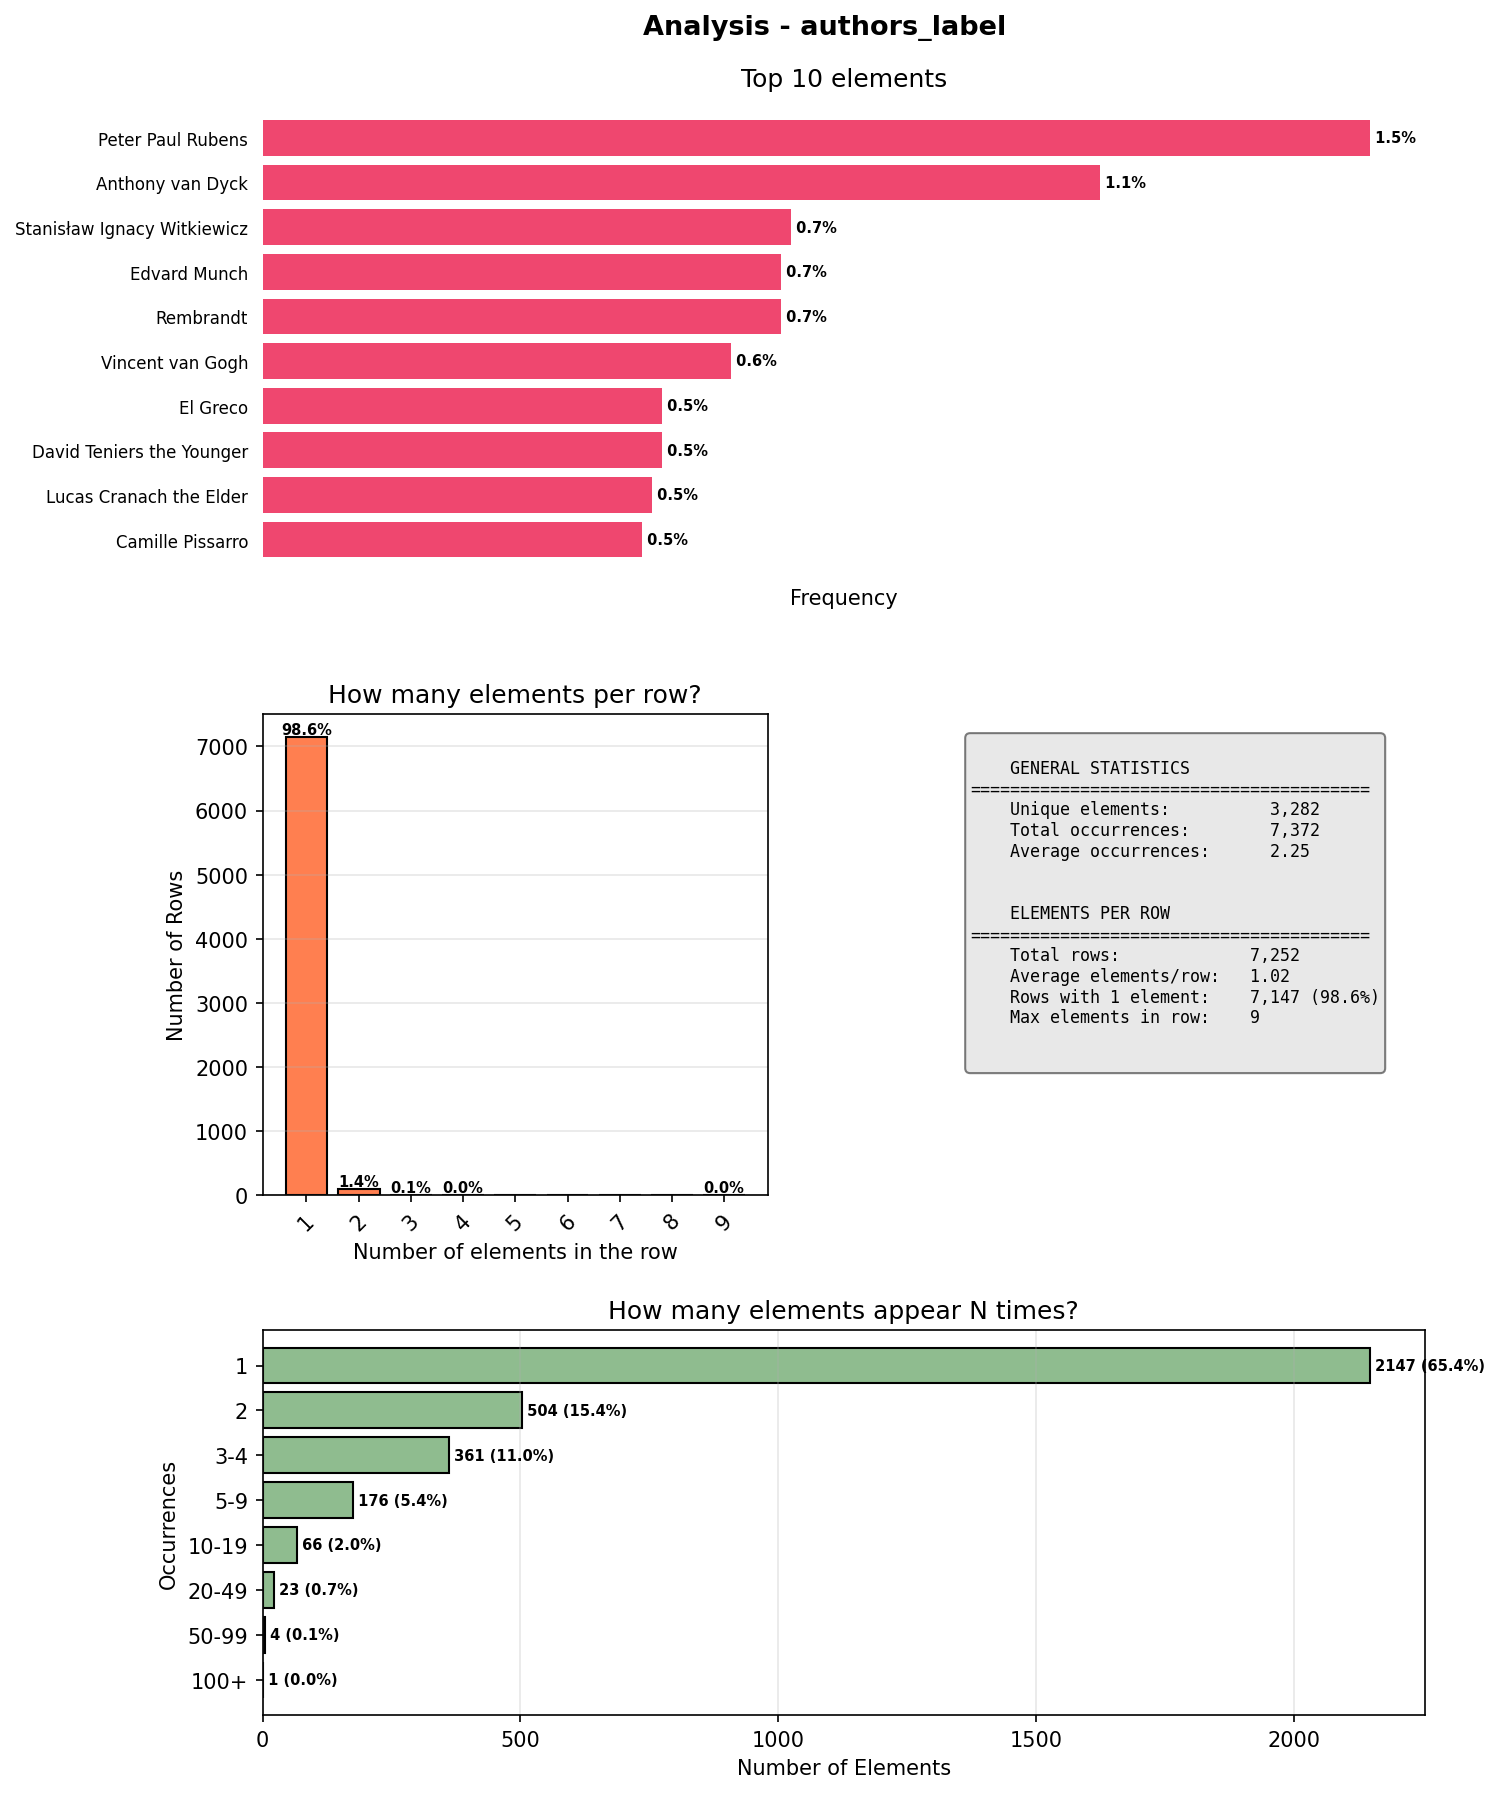

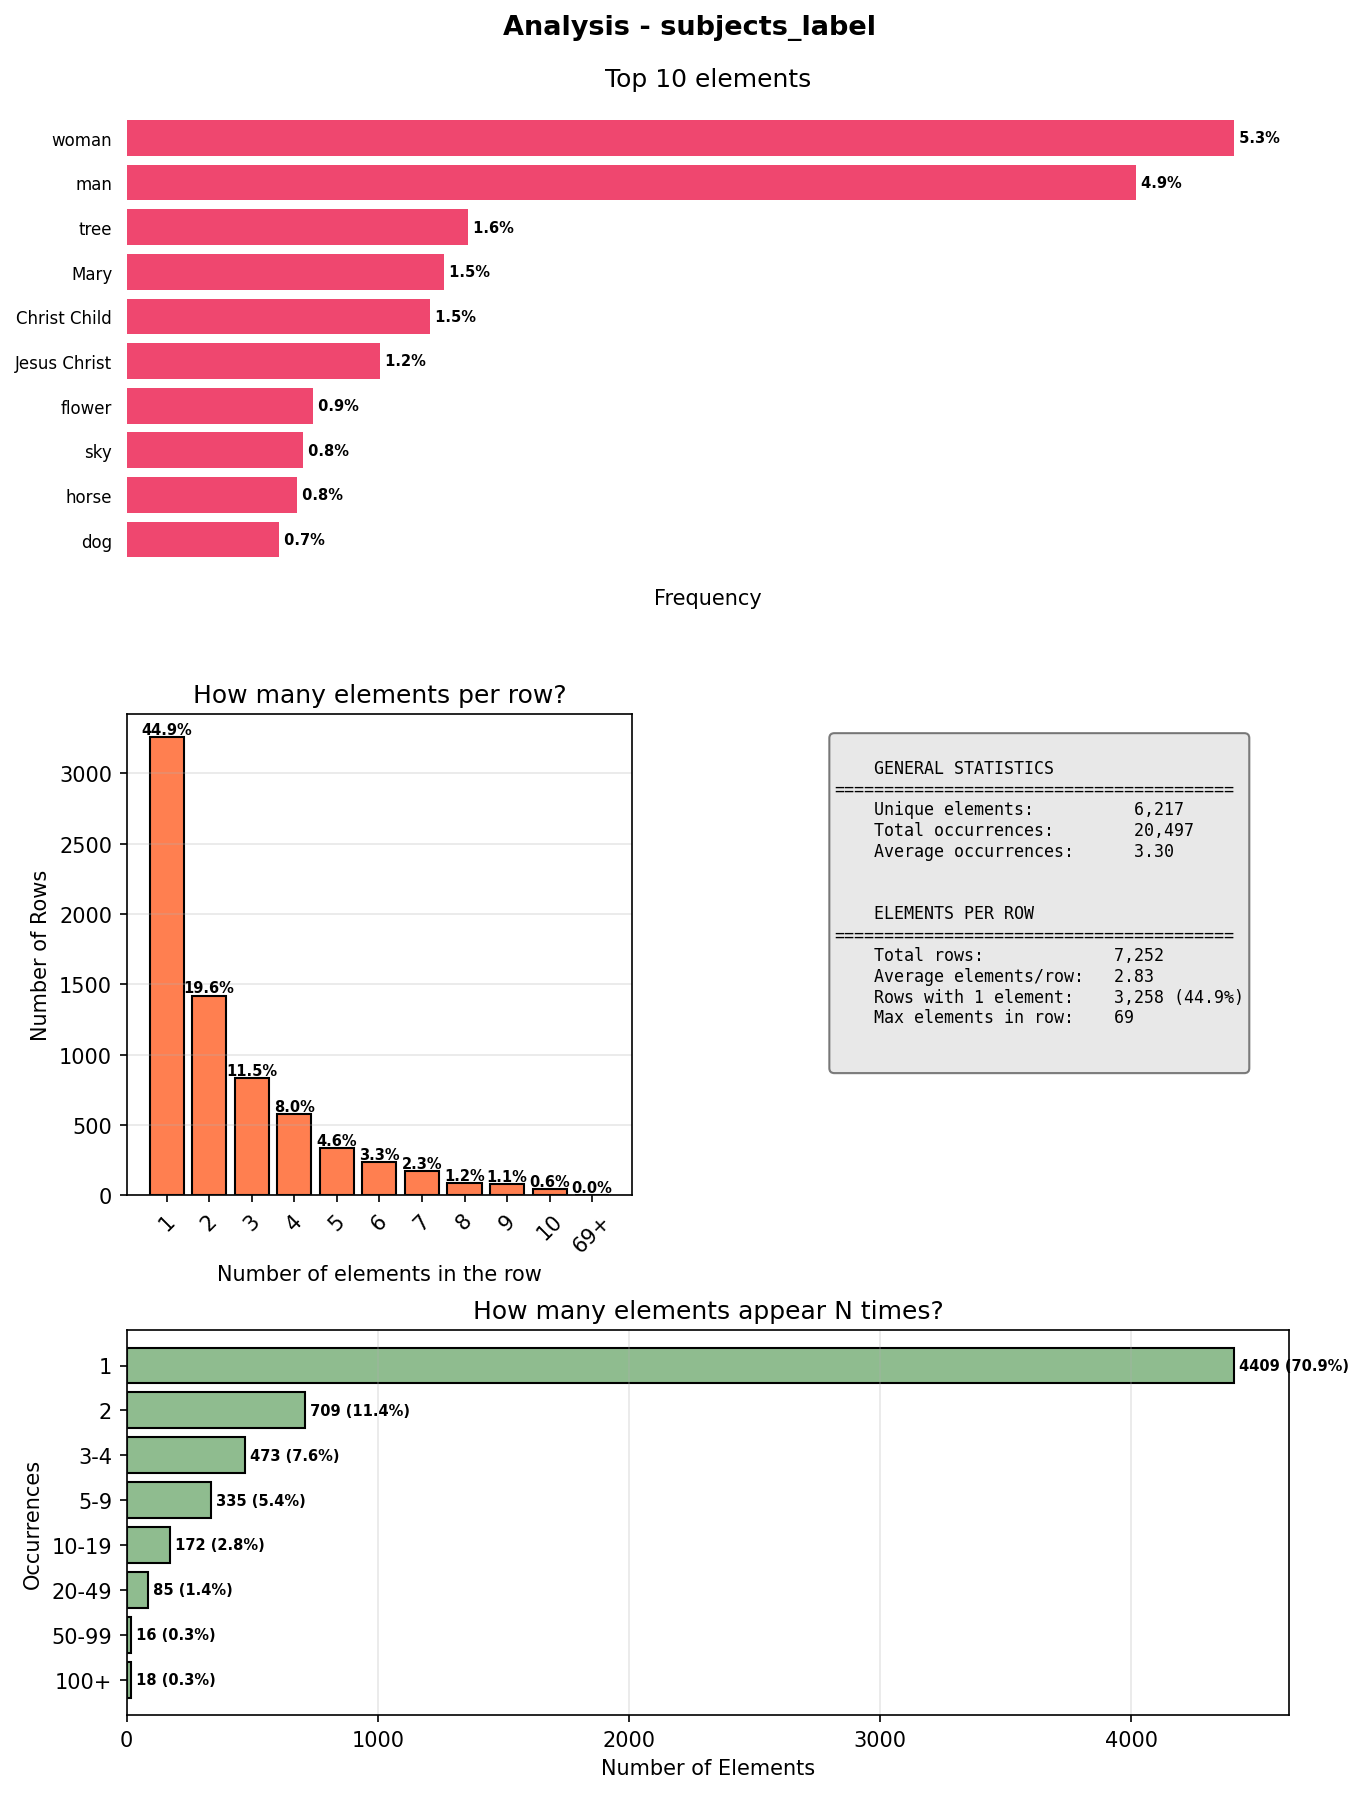

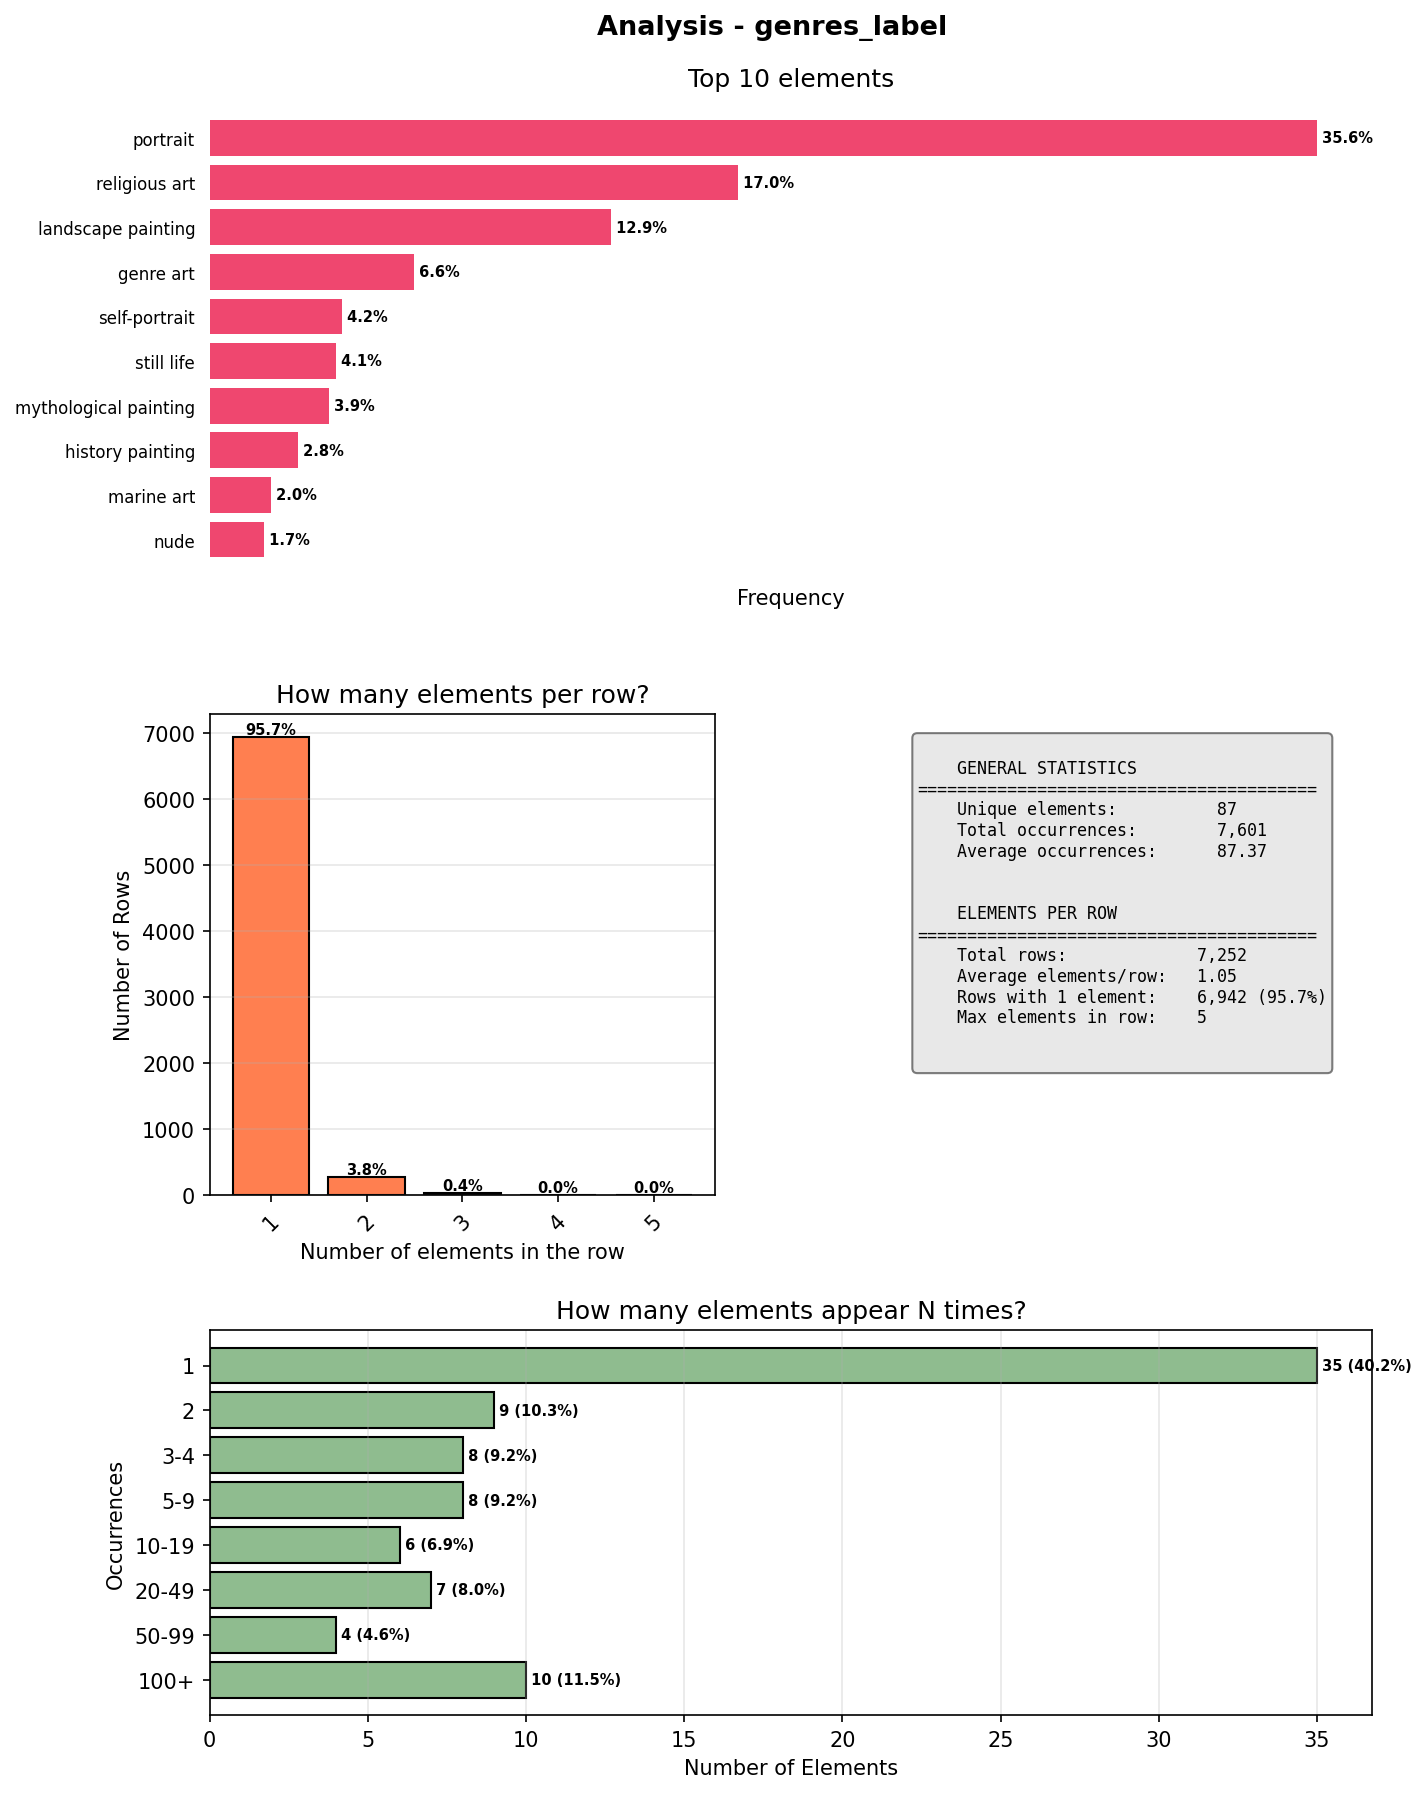

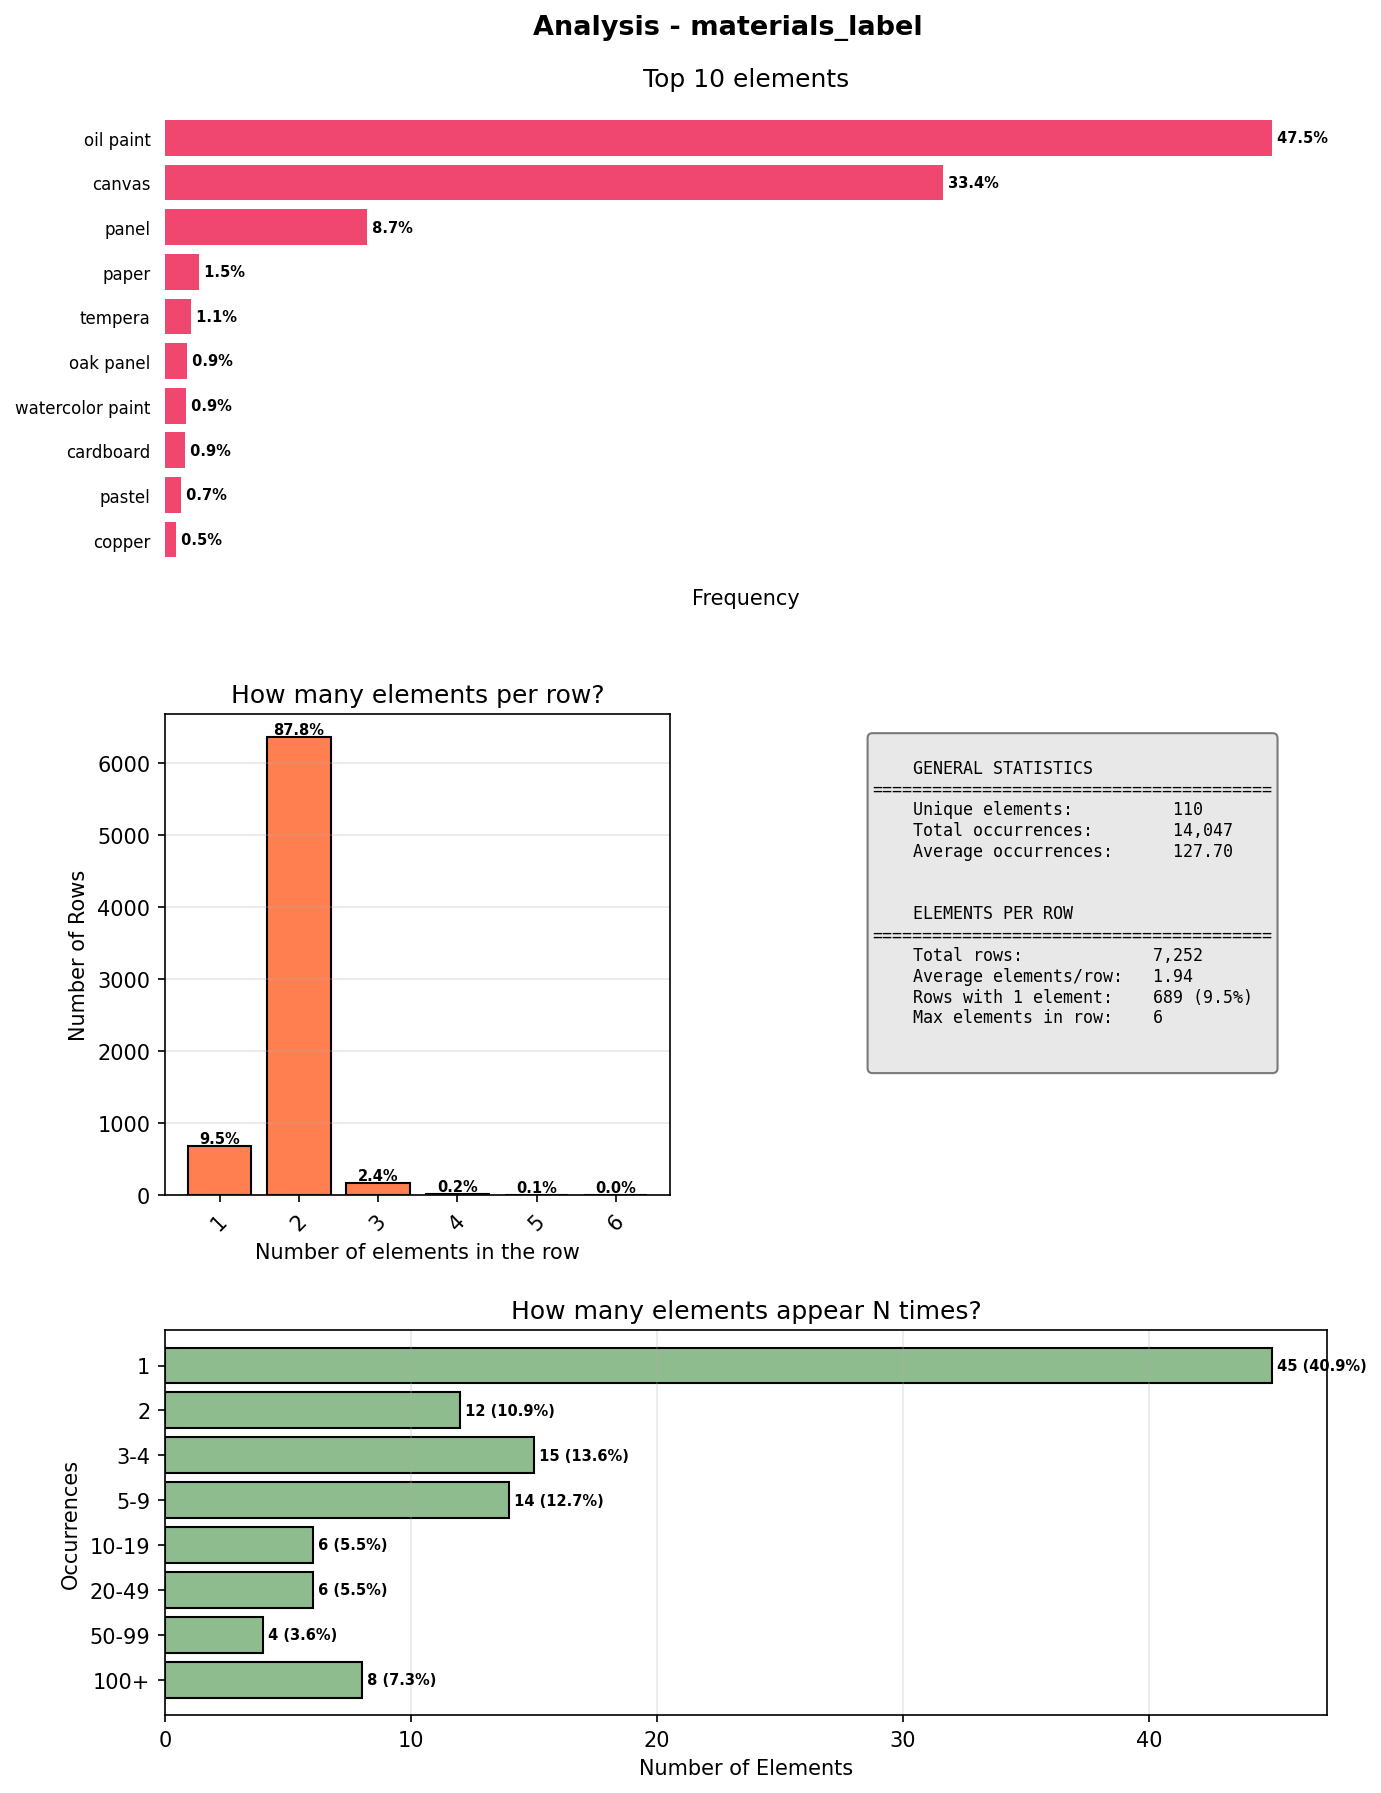

In [ ]:
train_path = '/content/drive/MyDrive/Dataset/train.csv'

df = pd.read_csv(train_path)

for col in df.columns:
    esempio = df[col].dropna().iloc[0] if len(df[col].dropna()) > 0 else ""

    if str(esempio).startswith('['):
        df[col] = df[col].apply(normalize_list_column)

df_stats = df.drop(columns=['artefact', 'type_label', 'artefact_label', 'description', 'images'])

distribuzioni = {}

for col in df_stats.columns:

    distribuzioni[col] = {}

    for val in df_stats[col]:
        if pd.notna(val) and val != '':
            elementi = val.split(',')

            for elemento in elementi:
                elemento = elemento.strip()

                if elemento:
                    if elemento in distribuzioni[col]:
                        distribuzioni[col][elemento] += 1
                    else:
                        distribuzioni[col][elemento] = 1

for col in ['authors_label', 'subjects_label', 'genres_label', 'materials_label']:
    fig = crea_dashboard_distribuzione(distribuzioni[col], col, df_stats, top_n=10)
    plt.show()
    print("\n")

## Co-occurrence metrics

In [ ]:
def calcola_cooccorrenza(df, colonna):
    """
    Compute the co-occurrence matrix for a column
    """

    cooccorrenze = defaultdict(int)

    for idx, val in enumerate(df[colonna]):
        if pd.notna(val) and val != '':
            elementi = [e.strip() for e in val.split(',') if e.strip()]

            for elem1, elem2 in combinations(sorted(elementi), 2):
                cooccorrenze[(elem1, elem2)] += 1

    return dict(cooccorrenze)


In [ ]:
def stampa_top_cooccorrenze(cooccorrenze_dict, nome_colonna, top_n=20):
    """
    Print the most frequent co-occurrences
    """
    top_coppie = sorted(cooccorrenze_dict.items(),
                       key=lambda x: x[1], reverse=True)[:top_n]

    print(f"\n{'='*80}")
    print(f"TOP {top_n} CO-OCCURENCES - {nome_colonna}")
    print(f"{'='*80}")

    for i, ((val1, val2), count) in enumerate(top_coppie, 1):
        val1_short = val1[:35] + '...' if len(val1) > 35 else val1
        val2_short = val2[:35] + '...' if len(val2) > 35 else val2
        print(f"{i:2}. [{count:4}x] {val1_short:40} ↔ {val2_short}")

In [ ]:
def crea_heatmap_cooccorrenza(cooccorrenze_dict, nome_colonna, top_n=20):
    """
    Create a heatmap of the most frequent co-occurrences
    """

    top_coppie = sorted(cooccorrenze_dict.items(),
                       key=lambda x: x[1], reverse=True)[:top_n]

    if not top_coppie:
        print(f"No co-occurence found for {nome_colonna}")
        return None

    valori_unici = set()
    for (val1, val2), _ in top_coppie:
        valori_unici.add(val1)
        valori_unici.add(val2)

    valori_lista = sorted(list(valori_unici))
    n_valori = len(valori_lista)

    matrice = np.zeros((n_valori, n_valori))

    val_to_idx = {val: idx for idx, val in enumerate(valori_lista)}

    for (val1, val2), count in cooccorrenze_dict.items():
        if val1 in val_to_idx and val2 in val_to_idx:
            idx1 = val_to_idx[val1]
            idx2 = val_to_idx[val2]
            matrice[idx1, idx2] = count
            matrice[idx2, idx1] = count

    fig, ax = plt.subplots(figsize=(8, 8))

    labels_brevi = [val[:30] + '...' if len(val) > 30 else val
                    for val in valori_lista]

    sns.heatmap(matrice,
                xticklabels=labels_brevi,
                yticklabels=labels_brevi,
                cmap='YlOrRd',
                annot=True,
                fmt='.0f',
                cbar_kws={'label': 'Number of co-occurences'},
                square=True,
                linewidths=0.5,
                ax=ax)

    plt.title(f'Co-occurrence Matrix - {nome_colonna}\n(Top {top_n} more frequent couples)',
              fontsize=14, fontweight='bold', pad=20)
    plt.xticks(rotation=45, ha='right', fontsize=9)
    plt.yticks(rotation=0, fontsize=9)
    plt.tight_layout()

    return fig

### Print top 15 co-occorrurences

In [ ]:
cooccorrenze = {}
for col in df_stats.columns:
    cooccorrenze[col] = calcola_cooccorrenza(df_stats, col)

for col in cooccorrenze:
    stampa_top_cooccorrenze(cooccorrenze[col], col, top_n=15)


TOP 15 CO-OCCURENCES - genres_label
 1. [  47x] portrait                                 ↔ self-portrait
 2. [  20x] genre art                                ↔ landscape painting
 3. [  18x] mythological painting                    ↔ nude
 4. [  13x] history painting                         ↔ portrait
 5. [  12x] genre art                                ↔ nude
 6. [  11x] genre art                                ↔ portrait
 7. [  11x] nude                                     ↔ religious art
 8. [   9x] landscape painting                       ↔ mythological painting
 9. [   9x] nude                                     ↔ portrait
10. [   8x] group portrait                           ↔ portrait
11. [   7x] landscape painting                       ↔ marine art
12. [   7x] floral painting                          ↔ still life
13. [   7x] landscape painting                       ↔ religious art
14. [   6x] genre art                                ↔ self-portrait
15. [   5x] double portrait 

### Heat map top 15 co-occurrences

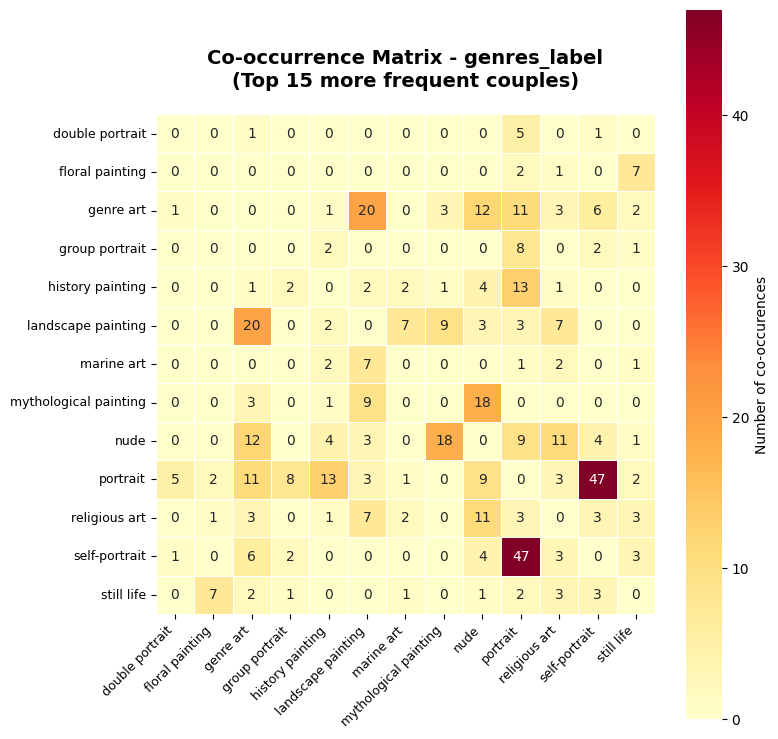

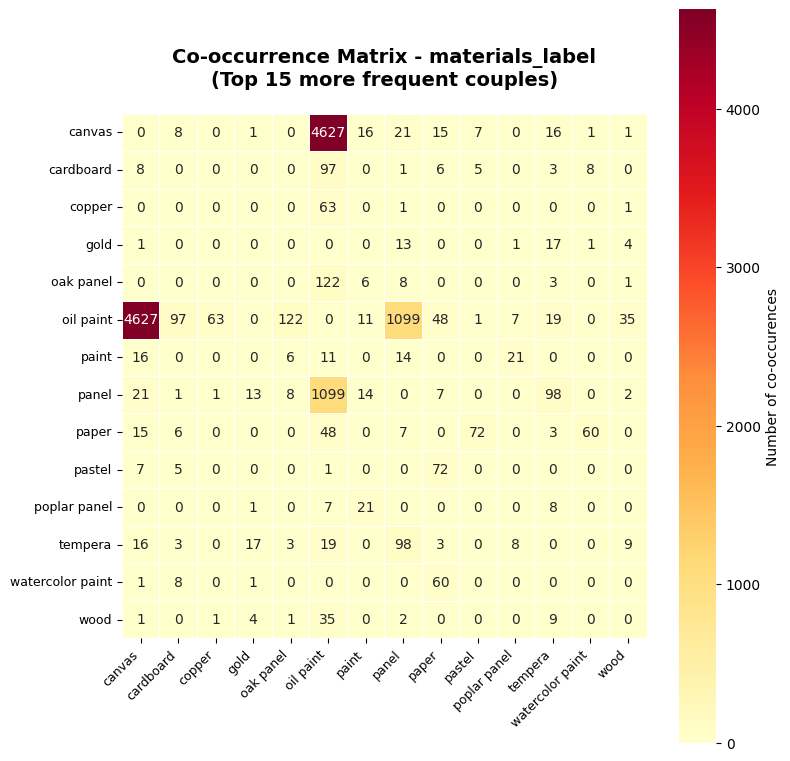

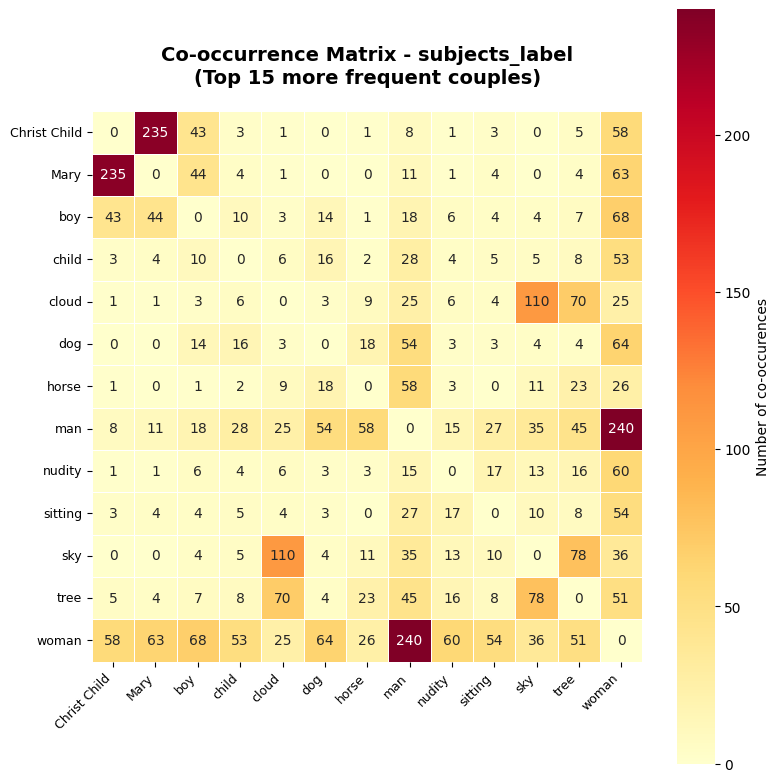

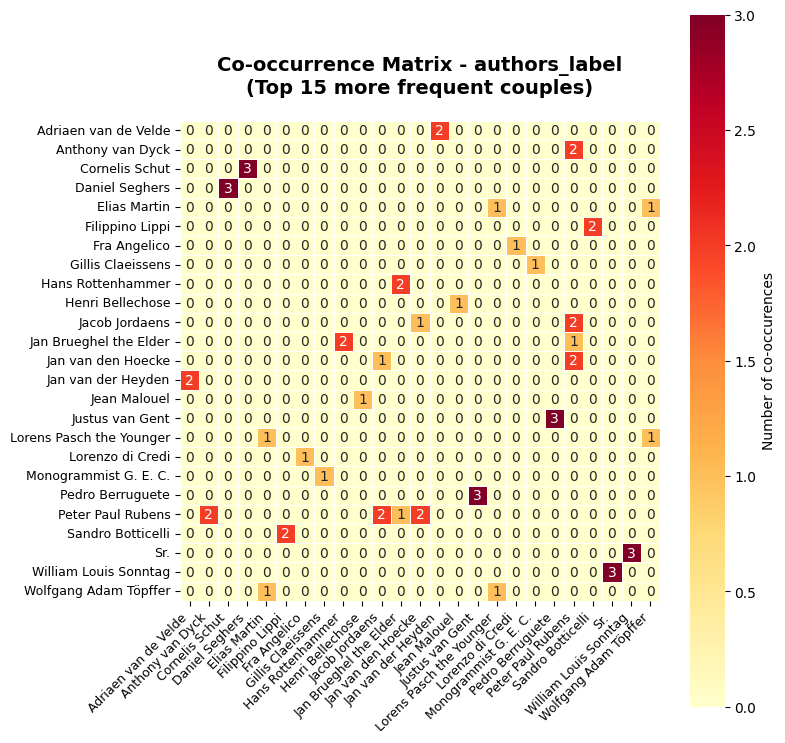

In [ ]:
for col in cooccorrenze:
  fig = crea_heatmap_cooccorrenza(cooccorrenze[col], col, top_n=15)
  plt.show()

# **ZERO–SHOT EVALUATION**

Perform inference on images using a Visual Language Model (VLM) across multiple categories (authors, materials, genres, subjects). The process involves four main steps:

1. **Environment Setup & Data Loading**: It extracts the image dataset (foto.zip) into local storage for efficient access and creates a dictionary mapping to link image IDs to their specific file paths.

2. **Response Parsing Utility**: A helper function (parse_json_response) is defined to robustly clean and extract structured JSON data from the model's raw text output. It specifically handles Markdown artifacts (like ```json blocks) and parsing errors using Regex to ensure reliable data extraction.

3. **Inference Logic**: The core function (run_inference_on_category) iterates through the dataset. For each image, it:

    - Dynamically selects a category-specific prompt (e.g., utilizing select_prompt to fetch specific instructions for materials vs. authors).



    - Processes the visual and textual inputs for the model using the processor.

    - Generates a response and parses the result into a standardized format using the utility defined in step 2.

4. **Batch Execution**: Finally, the script loops through the target categories (authors, materials, genres, subjects), runs the inference pipeline for each, and aggregates the predictions alongside the ground truth into a dictionary (all_results) for future evaluation.

## **QWEN2-VL-INSTRUCT**

In [ ]:
def parse_json_response(output_text, category):
    """
    Extracts visual_analysis and artist from the JSON response
    """
    try:
        cleaned = output_text.strip()

        cleaned = re.sub(r'^```(?:json)?\s*', '', cleaned)
        cleaned = re.sub(r'\s*```$', '', cleaned)

        start = cleaned.find('{')
        end = cleaned.rfind('}')

        if start == -1 or end == -1:
            raise ValueError("No valid JSON found")

        json_str = cleaned[start:end+1]
        data = json.loads(json_str)

        category = data.get(category, data.get(category, []))

        if isinstance(category, str):
            category = [category]

        category_str = ', '.join(category) if category else ''

        return category_str

    except json.JSONDecodeError as e:
        print(f"    JSON parsing error: {e}")
        print(f"    Raw output (first 300 chars): {output_text[:300]}")
        print(f"    Cleaned (first 300 chars): {cleaned[:300] if 'cleaned' in locals() else 'N/A'}")
        return "JSON Error", ''
    except Exception as e:
        print(f"    Generic error: {e}")
        print(f"    Raw output: {output_text[:200]}")
        return "Error", ''

In [ ]:
def load_image(image_id):
    path = id_to_path.get(str(image_id))
    if path is None:
        raise FileNotFoundError(f"No file found for id {image_id}")
    return path

In [ ]:
def normalize_list_column(value):
    """
    Convert "['item1', 'item2']" in "item1, item2"
    """
    if pd.isna(value) or value == '[]' or value == '':
        return ''

    cleaned = str(value).replace('[', '').replace(']', '').replace("'", "").replace('"', '')

    items = [item.strip() for item in cleaned.split(',') if item.strip()]

    return ', '.join(items)

In [ ]:
zip_path = "/content/drive/MyDrive/Dataset/foto.zip"

dest_path = "/content/dataset_veloce"

!unzip -q -o "{zip_path}" -d "{dest_path}"

folder = "/content/dataset_veloce/foto"

id_to_path = {os.path.splitext(f)[0]: os.path.join(folder, f)
              for f in os.listdir(folder)}

### **PROMPTS**

In [ ]:
def create_materials_prompt():
    prompt = """You are an expert art historian. Analyze this painting and identify its material(s).

Provide structured JSON with visual description and material attribution.

Steps:
1. Visual Analysis: Describe surface texture, finish, opacity, application technique, and visual characteristics
2. Material Indicators: Identify distinctive features (texture patterns, sheen, layering effects, medium properties) that indicate specific material(s)
3. Mixed Media Detection: Note any characteristics suggesting use of multiple materials or combined techniques
4. Classification: Determine the most likely material(s) and support based on visual evidence

Rules: Identify ANY material from visual analysis. List ALL materials.

Output ONLY valid JSON:
{"materials": ["Material Name"]}

CRITICAL: Your response must be valid JSON. Always close with ]}"""
    return prompt

In [ ]:
def create_authors_prompt():
    prompt = """You are an expert art historian. Analyze this painting and identify its author(s).

Provide structured JSON with visual description and artist attribution.

Steps:
1. Visual Analysis: Describe style, technique, color palette, composition, subject matter, and period characteristics
2. Artist Identification: Identify distinctive features (brushwork, signature style, color use, composition patterns) that indicate specific artist(s)
3. Collaboration Detection: Note any stylistic inconsistencies suggesting multiple artists
4. Classification: Determine the most likely artist(s) based on visual evidence

Rules: Identify ANY artist from visual analysis. List ALL artists if collaboration detected.

Output ONLY valid JSON:
{"artists": ["Full Name"]}

CRITICAL: Your response must be valid JSON. Always close with ]}"""
    return prompt

In [ ]:
def create_genres_prompt():
    prompt = """You are an expert art historian. Analyze this artwork and identify the genre depicted.

Provide structured JSON with genres attribution.

Steps:

1. Visual Analysis: Describe style, technique, color palette, composition, subject matter, and period characteristics
2. Genre Indicators: Identify distinctive features (subject matter, composition conventions, thematic elements, stylistic patterns) that indicate specific genre(s)
3. Mixed Genre Detection: Note any characteristics suggesting hybrid or multiple genre influences
4. Classification: Determine the most likely genre(s) based on visual evidence

Rules: Identify ANY genre(s) from visual analysis. List ALL genre(s).

OUTPUT ONLY valid JSON:
{"genres": ["genre1", "genre2", "genre3"]}


CRITICAL: Your response must be valid JSON. Always close with ]}"""
    return prompt

In [ ]:
def create_subjects_prompt():
    prompt = """You are an expert art historian. Analyze this artwork and identify the subject(s) depicted.

Provide structured JSON with subjects attribution.

Steps:

1. Visual Analysis: Describe style, technique, color palette, composition, subject matter, and period characteristics
2. Subject Indicators: Identify distinctive features (subject matter, composition conventions, thematic elements, stylistic patterns) that indicate specific subject(s)
3. Subject Detection: Note any characteristics suggesting subjects
4. Classification: Determine the most likely subject(s) based on visual evidence

Rules: Identify ANY subject(s) from visual analysis. List ALL subject(s).

OUTPUT ONLY valid JSON:
{"subjects": ["subject1", "subject2", "subject3"]}


CRITICAL: Your response must be valid JSON. Always close with ]}"""
    return prompt

In [ ]:
def select_prompt(category):

    if category == 'authors':
      create_authors_prompt()

    elif category == 'materials':
      create_materials_prompt()

    elif category == 'subjects':
      create_subjects_prompt()

    elif category == 'genres':
      create_genres_prompt()


### EXECUTION

In [ ]:
def run_inference_on_category(df, category, processor, model, device="cuda"):
    """
    Wrapper for performing inference across different categories.
    Supports: authors, materials, subjects, genres.
    """

    for col in df.columns:
      esempio = df[col].dropna().iloc[0] if len(df[col].dropna()) > 0 else ""

      if str(esempio).startswith('['):
        df[col] = df[col].apply(normalize_list_column)

    label_map = {
        "authors": "authors_label",
        "materials": "materials_label",
        "subjects": "subjects_label",
        "genres": "genres_label"
    }

    gt_column = label_map.get(category, f"{category}_label")

    predictions = []
    print(f"--- Starting inference for category: {category.upper()} on {len(df)} rows ---")

    for row in df.itertuples():
        try:
            image_path = load_image(row.images)

            prompt = select_prompt(category)

            messages = [
                {
                    "role": "user",
                    "content": [
                        {"type": "image", "image": image_path},
                        {"type": "text", "text": prompt},
                    ],
                }
            ]

            text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
            image_inputs, video_inputs = process_vision_info(messages)

            inputs = processor(
                text=[text],
                images=image_inputs,
                videos=video_inputs,
                padding=True,
                return_tensors="pt",
            ).to(device)

            generated_ids = model.generate(
                **inputs,
                max_new_tokens=256,
                do_sample=True,
                temperature=0.2,
                top_p=0.7,
                repetition_penalty=1.05,
            )

            generated_ids_trimmed = [out_ids[len(in_ids):] for in_ids, out_ids in zip(inputs.input_ids, generated_ids)]
            output_text = processor.batch_decode(generated_ids_trimmed, skip_special_tokens=True)[0]

            parsed_result = parse_json_response(output_text, key=category)

            predictions.append({
                "image_id": row.images,
                "category": category,
                "pred": parsed_result,
                "gt": getattr(row, gt_column)
            })

            print(f"[{category}] Image: {row.images} | Pred: {parsed_result}")

        except Exception as e:
          print(f"Error ID {row.images} for {category}: {e}")
    return predictions

In [ ]:
processor = AutoProcessor.from_pretrained("Qwen/Qwen2-VL-2B-Instruct")
model = AutoModelForVision2Seq.from_pretrained("Qwen/Qwen2-VL-2B-Instruct")

device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to("cuda")

In [ ]:
val_path = '/content/drive/MyDrive/Dataset/train.csv'

df = pd.read_csv(val_path)

all_results = {}
categories_to_test = ["authors", "materials", "genres", "subjects"]

for cat in categories_to_test:
    results = run_inference_on_category(df, cat, processor, model)
    all_results[cat] = results


## **BLIP2-FLAN-T5**

In [ ]:
def parse_response(output_text, category, prompt_text=""):

    try:
        cleaned = output_text.replace(prompt_text, "").strip()
        cleaned = cleaned.replace("Answer:", "").strip()

        if category == 'authors':
            prefixes = ["artist:", "the artist is", "painted by", "created by"]
            for prefix in prefixes:
                if cleaned.lower().startswith(prefix):
                    cleaned = cleaned[len(prefix):].strip()
                    break
            cleaned = re.sub(r'\([^)]*\)', '', cleaned)
            cleaned = re.sub(r'\d+', '', cleaned)
            cleaned = cleaned.rstrip('.,;:!?')
            return cleaned.strip() if len(cleaned) > 2 else "Unknown"

        else:
            items = [s.strip().strip('.').lower() for s in cleaned.split(',')]
            valid_items = [s for s in items if s and len(s) > 1]
            return ', '.join(valid_items) if valid_items else "Unknown"

    except Exception as e:
        print(f"    Parsing error: {e}")
        return "Error"

In [ ]:
def load_image(image_id):
    path = id_to_path.get(str(image_id))
    if path is None:
        raise FileNotFoundError(f"No file found for id {image_id}")
    return path

In [ ]:
def normalize_list_column(value):
    """
    Convert "['item1', 'item2']" in "item1, item2"
    """
    if pd.isna(value) or value == '[]' or value == '':
        return ''

    cleaned = str(value).replace('[', '').replace(']', '').replace("'", "").replace('"', '')

    items = [item.strip() for item in cleaned.split(',') if item.strip()]

    return ', '.join(items)

In [ ]:
zip_path = "/content/drive/MyDrive/Dataset/foto.zip"

dest_path = "/content/dataset_veloce"

!unzip -q -o "{zip_path}" -d "{dest_path}"

folder = "/content/dataset_veloce/foto"

id_to_path = {os.path.splitext(f)[0]: os.path.join(folder, f)
              for f in os.listdir(folder)}

### **PROMPTS**

In [ ]:
def select_prompt(category):

    if category == 'authors':
        return """What is the first and last name of the person who painted this picture?
        Artist is:"""

    elif category == 'materials':
        return """What are the main materials of this painting?
        Material:"""

    elif category == 'subjects':
        return """What are the main subjects in this painting?
        Subjects are:"""

    elif category == 'genres':
        return """What are the artistic genres of this painting?
        Genre:"""

    return "Describe this image."

### **EXECUTION**

In [ ]:
from PIL import Image

def run_inference_on_category(df, category, processor, model, device="cuda"):
    """
    Wrapper for performing inference across different categories.
    """

    for col in df.columns:
        esempio = df[col].dropna().iloc[0] if len(df[col].dropna()) > 0 else ""
        if str(esempio).startswith('['):
            df[col] = df[col].apply(normalize_list_column)

    label_map = {
        "authors": "authors_label",
        "materials": "materials_label",
        "subjects": "subjects_label",
        "genres": "genres_label"
    }

    gt_column = label_map.get(category, f"{category}_label")
    predictions = []

    print(f"--- Starting inference for category: {category.upper()} on {len(df)} rows ---")

    for row in df.itertuples():
        try:
            image_path = load_image(row.images)
            raw_image = Image.open(image_path).convert('RGB')

            prompt = select_prompt(category)

            inputs = processor(images=raw_image, text=prompt, return_tensors="pt").to(device)

            generated_ids = model.generate(
                **inputs,
                max_new_tokens=256,
                do_sample=True,
                temperature=0.2,
                top_p=0.7,
                repetition_penalty=1.05,
            )

            output_text = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]

            parsed_result = parse_response(output_text, category, prompt_text=prompt)

            predictions.append({
                "image_id": row.images,
                "category": category,
                "pred": parsed_result,
                "gt": getattr(row, gt_column)
            })

            print(f"[{category}] Image: {row.images} | Pred: {parsed_result}")

        except Exception as e:
            print(f"✗ Error ID {row.images} for {category}: {e}")
            predictions.append({
                "image_id": row.images,
                "category": category,
                "pred": "Error",
                "gt": getattr(row, gt_column)
            })

    return predictions

In [ ]:
processor = AutoProcessor.from_pretrained("Salesforce/blip2-flan-t5-xl")
model = AutoModelForVision2Seq.from_pretrained("Salesforce/blip2-flan-t5-xl")

device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to("cuda")

In [ ]:
val_path = '/content/drive/MyDrive/ADSP/Dataset/val.csv'

df = pd.read_csv(val_path)

all_results = {}
categories_to_test = ["authors", "materials", "genres", "subjects"]

for cat in categories_to_test:
    results = run_inference_on_category(df, cat, processor, model, device=device)
    all_results[cat] = results

# **FINE–TUNING**

The methodology focuses on Fine-Tuning the highest-performing baseline model to optimize its predictive capabilities. To achieve this efficiently, the project utilizes PEFT (Parameter-Efficient Fine-Tuning) techniques, which update only a small subset of parameters rather than retraining the entire model.

Three distinct architectural strategies were evaluated for handling metadata categories:

1. **Multi-Model**: A specialized approach involving four distinct model versions, each independently fine-tuned and dedicated to a single metadata category to maximize task specialization.

2. **Single-Model (1 Image - 4 Prompts)**: A targeted approach where the model processes four independent prompts per image. This focuses on specific task analysis but increases computational demand.

3. **Single-Model (Single Prompt)**: A holistic approach where a single model predicts all four categories within one inference cycle, prioritizing comprehensive analysis over complexity.





## **MULTI–MODEL**

### **AUTHORS MODEL**

In [ ]:
def normalize_list_column(value):
    """
    Convert "['item1', 'item2']" in "item1, item2"
    """
    if pd.isna(value) or value == '[]' or value == '':
        return ''

    cleaned = str(value).replace('[', '').replace(']', '').replace("'", "").replace('"', '')

    items = [item.strip() for item in cleaned.split(',') if item.strip()]
    items.sort()

    return ', '.join(items)

In [ ]:
def prepare_cleaned_dataframe(csv_path):

    df = pd.read_csv(csv_path)

    for col in df.columns:
        sample = df[col].dropna().iloc[0] if len(df[col].dropna()) > 0 else ""
        if str(sample).startswith('['):
            df[col] = df[col].apply(normalize_list_column)

    df['full_path'] = df['images'].apply(lambda x: id_to_path.get(str(x)))

    return df.dropna(subset=['full_path', 'authors_label'])

In [ ]:
def prepare_dataset_list(dataframe, num_samples=None):

    if num_samples:
        dataframe = dataframe.head(num_samples)

    data_list = []

    for _, row in dataframe.iterrows():
        data_list.append({
            "image_id": str(row['images']),
            "full_path": row['full_path'],
            "author_gt": row['authors_label'],
            "messages": [
                {
                    "role": "user",
                    "content": [
                        {"type": "image", "image": row['full_path']},
                        {"type": "text", "text": PROMPT}
                    ]
                },
                {
                    "role": "assistant",
                    "content": [{"type": "text", "text": f"author: {row['authors_label']}"}]
                }
            ]
        })

    return data_list

In [ ]:
def collate_fn(examples):

    texts = [processor.apply_chat_template(ex["messages"], tokenize=False) for ex in examples]
    image_inputs, _ = process_vision_info([ex["messages"] for ex in examples])

    batch = processor(text=texts, images=image_inputs, return_tensors="pt", padding=True)
    labels = batch["input_ids"].clone()

    assistant_prefix_ids = processor.tokenizer.encode("<|im_start|>assistant", add_special_tokens=False)

    for i in range(labels.shape[0]):
        found_idx = -1
        for j in range(len(labels[i]) - len(assistant_prefix_ids)):
            if labels[i, j : j + len(assistant_prefix_ids)].tolist() == assistant_prefix_ids:
                found_idx = j + len(assistant_prefix_ids)
        if found_idx != -1:
            labels[i, :found_idx] = -100
        else:
            labels[i, :] = -100

    batch["labels"] = labels

    return batch

In [ ]:
## Dataset & Prompt ##

zip_path = "/content/drive/MyDrive/Dataset/foto.zip"
dest_path = "/content/dataset_veloce"

images_folder = "/content/dataset_veloce/foto"

if not os.path.exists(dest_path):
    !unzip -q -o "{zip_path}" -d "{dest_path}"

id_to_path = {os.path.splitext(f)[0]: os.path.join(images_folder, f)
              for f in os.listdir(images_folder)}

df_train = prepare_cleaned_dataframe("/content/drive/MyDrive/Dataset/train.csv")

train_data = prepare_dataset_list(df_train)

PROMPT = "Identify the author(s) of this artwork. Answer with the format 'author: name'."

In [ ]:
## Training ##

model_id = "Qwen/Qwen2-VL-2B-Instruct"
processor = AutoProcessor.from_pretrained(model_id)
model = Qwen2VLForConditionalGeneration.from_pretrained(
    model_id, torch_dtype=torch.bfloat16, device_map="auto"
)

lora_config = LoraConfig(
    r=16, lora_alpha=32,
    target_modules=[
        "visual.merger.mlp.0",
        "visual.merger.mlp.2",
        "model.layers.*.self_attn.q_proj",
        "model.layers.*.self_attn.k_proj",
        "model.layers.*.self_attn.v_proj",
        "model.layers.*.self_attn.o_proj",
        "model.layers.*.mlp.gate_proj",
        "model.layers.*.mlp.up_proj",
        "model.layers.*.mlp.down_proj",
        ],
    lora_dropout=0.05, bias="none", task_type="CAUSAL_LM"
)

model = get_peft_model(model, lora_config)

training_args = TrainingArguments(
    output_dir="./qwen-finetuned",
    per_device_train_batch_size=2,
    gradient_accumulation_steps=8,
    num_train_epochs=2,
    learning_rate=2e-4,
    bf16=True,
    logging_steps=50,
    remove_unused_columns=False,
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_data,
    data_collator=collate_fn
)

print(f"\n--- Start of training ---")
trainer.train()

In [ ]:
## Saving Model ##

drive_model_path = "/content/drive/MyDrive/ADSP/TRAIN/Multi_Model/authors_model"

trainer.save_model(drive_model_path)

processor.save_pretrained(drive_model_path)

print(f"Model successfully saved in: {drive_model_path}")

### **MATERIALS MODEL**

In [ ]:
def normalize_list_column(value):
    """
    Convert "['item1', 'item2']" in "item1, item2"
    """
    if pd.isna(value) or value == '[]' or value == '':
        return ''

    cleaned = str(value).replace('[', '').replace(']', '').replace("'", "").replace('"', '')

    items = [item.strip() for item in cleaned.split(',') if item.strip()]
    items.sort()

    return ', '.join(items)

In [ ]:
def prepare_cleaned_dataframe(csv_path):

    df = pd.read_csv(csv_path)

    for col in df.columns:
        sample = df[col].dropna().iloc[0] if len(df[col].dropna()) > 0 else ""
        if str(sample).startswith('['):
            df[col] = df[col].apply(normalize_list_column)

    df['full_path'] = df['images'].apply(lambda x: id_to_path.get(str(x)))

    return df.dropna(subset=['full_path', 'materials_label'])

In [ ]:
def prepare_dataset_list(dataframe, num_samples=None):

    if num_samples:
        dataframe = dataframe.head(num_samples)

    data_list = []

    for _, row in dataframe.iterrows():
        data_list.append({
            "image_id": str(row['images']),
            "full_path": row['full_path'],
            "material_gt": row['materials_label'],
            "messages": [
                {
                    "role": "user",
                    "content": [
                        {"type": "image", "image": row['full_path']},
                        {"type": "text", "text": PROMPT}
                    ]
                },
                {
                    "role": "assistant",
                    "content": [{"type": "text", "text": f"material: {row['materials_label']}"}]
                }
            ]
        })
    return data_list

In [ ]:
def collate_fn(examples):

    texts = [processor.apply_chat_template(ex["messages"], tokenize=False) for ex in examples]
    image_inputs, _ = process_vision_info([ex["messages"] for ex in examples])

    batch = processor(text=texts, images=image_inputs, return_tensors="pt", padding=True)
    labels = batch["input_ids"].clone()

    assistant_prefix_ids = processor.tokenizer.encode("<|im_start|>assistant", add_special_tokens=False)

    for i in range(labels.shape[0]):
        found_idx = -1
        for j in range(len(labels[i]) - len(assistant_prefix_ids)):
            if labels[i, j : j + len(assistant_prefix_ids)].tolist() == assistant_prefix_ids:
                found_idx = j + len(assistant_prefix_ids)
        if found_idx != -1:
            labels[i, :found_idx] = -100
        else:
            labels[i, :] = -100

    batch["labels"] = labels

    return batch

In [ ]:
## Dataset & Prompt ##

zip_path = "/content/drive/MyDrive/Dataset/foto.zip"
dest_path = "/content/dataset_veloce"

images_folder = "/content/dataset_veloce/foto"

if not os.path.exists(dest_path):
    !unzip -q -o "{zip_path}" -d "{dest_path}"

id_to_path = {os.path.splitext(f)[0]: os.path.join(images_folder, f)
              for f in os.listdir(images_folder)}

df_train = prepare_cleaned_dataframe("/content/drive/MyDrive/Dataset/train.csv")

train_data = prepare_dataset_list(df_train)

PROMPT = "Identify the material(s) used in this artwork. Answer with the format 'material: name'."

In [ ]:
## Training ##

model_id = "Qwen/Qwen2-VL-2B-Instruct"
processor = AutoProcessor.from_pretrained(model_id)
model = Qwen2VLForConditionalGeneration.from_pretrained(
    model_id, torch_dtype=torch.bfloat16, device_map="auto"
)

lora_config = LoraConfig(
    r=16, lora_alpha=32,
    target_modules=[
        "visual.merger.mlp.0",
        "visual.merger.mlp.2",
        "model.layers.*.self_attn.q_proj",
        "model.layers.*.self_attn.k_proj",
        "model.layers.*.self_attn.v_proj",
        "model.layers.*.self_attn.o_proj",
        "model.layers.*.mlp.gate_proj",
        "model.layers.*.mlp.up_proj",
        "model.layers.*.mlp.down_proj",
        ],
    lora_dropout=0.05, bias="none", task_type="CAUSAL_LM"
)

model = get_peft_model(model, lora_config)

training_args = TrainingArguments(
    output_dir="./qwen-finetuned",
    per_device_train_batch_size=2,
    gradient_accumulation_steps=8,
    num_train_epochs=2,
    learning_rate=2e-4,
    bf16=True,
    logging_steps=50,
    remove_unused_columns=False,
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_data,
    data_collator=collate_fn
)

print(f"\n--- Start of training ---")
trainer.train()

In [ ]:
## Saving Model ##

drive_model_path = "/content/drive/MyDrive/ADSP/TRAIN/Multi_Model/material_model"

trainer.save_model(drive_model_path)

processor.save_pretrained(drive_model_path)

print(f"Model successfully saved in: {drive_model_path}")

### **GENRES MODEL**

In [ ]:
def normalize_list_column(value):
    """Converte "['item1', 'item2']" in "item1, item2" """

    if pd.isna(value) or value == '[]' or value == '':
        return ''

    cleaned = str(value).replace('[', '').replace(']', '').replace("'", "").replace('"', '')
    items = [item.strip() for item in cleaned.split(',') if item.strip()]
    items.sort()

    return ', '.join(items)

In [ ]:
def prepare_cleaned_dataframe(csv_path):

    df = pd.read_csv(csv_path)

    for col in df.columns:
        sample = df[col].dropna().iloc[0] if len(df[col].dropna()) > 0 else ""
        if str(sample).startswith('['):
            df[col] = df[col].apply(normalize_list_column)

    df['full_path'] = df['images'].apply(lambda x: id_to_path.get(str(x)))

    return df.dropna(subset=['full_path', 'genres_label'])

In [ ]:
def prepare_dataset_list(dataframe, num_samples=None):

    if num_samples:
        dataframe = dataframe.head(num_samples)

    data_list = []

    for _, row in dataframe.iterrows():
        data_list.append({
            "image_id": str(row['images']),
            "full_path": row['full_path'],
            "genre_gt": row['genres_label'],
            "messages": [
                {
                    "role": "user",
                    "content": [
                        {"type": "image", "image": row['full_path']},
                        {"type": "text", "text": PROMPT}
                    ]
                },
                {
                    "role": "assistant",
                    "content": [{"type": "text", "text": f"genre: {row['genres_label']}"}]
                }
            ]
        })

    return data_list

In [ ]:
def collate_fn(examples):

    texts = [processor.apply_chat_template(ex["messages"], tokenize=False) for ex in examples]
    image_inputs, _ = process_vision_info([ex["messages"] for ex in examples])

    batch = processor(text=texts, images=image_inputs, return_tensors="pt", padding=True)
    labels = batch["input_ids"].clone()

    assistant_prefix_ids = processor.tokenizer.encode("<|im_start|>assistant", add_special_tokens=False)

    for i in range(labels.shape[0]):
        found_idx = -1
        for j in range(len(labels[i]) - len(assistant_prefix_ids)):
            if labels[i, j : j + len(assistant_prefix_ids)].tolist() == assistant_prefix_ids:
                found_idx = j + len(assistant_prefix_ids)
        if found_idx != -1:
            labels[i, :found_idx] = -100
        else:
            labels[i, :] = -100

    batch["labels"] = labels

    return batch

In [ ]:
## Dataset & Prompt ##

zip_path = "/content/drive/MyDrive/Dataset/foto.zip"
dest_path = "/content/dataset_veloce"

images_folder = "/content/dataset_veloce/foto"

if not os.path.exists(dest_path):
    !unzip -q -o "{zip_path}" -d "{dest_path}"

id_to_path = {os.path.splitext(f)[0]: os.path.join(images_folder, f)
              for f in os.listdir(images_folder)}

df_train = prepare_cleaned_dataframe("/content/drive/MyDrive/Dataset/train.csv")

train_data = prepare_dataset_list(df_train)

PROMPT = "Identify the genre(s) of this artwork. Answer with the format 'genre: name'."

In [ ]:
## Training ##

model_id = "Qwen/Qwen2-VL-2B-Instruct"
processor = AutoProcessor.from_pretrained(model_id)
model = Qwen2VLForConditionalGeneration.from_pretrained(
    model_id, torch_dtype=torch.bfloat16, device_map="auto"
)

lora_config = LoraConfig(
    r=16, lora_alpha=32,
    target_modules=[
        "visual.merger.mlp.0",
        "visual.merger.mlp.2",
        "model.layers.*.self_attn.q_proj",
        "model.layers.*.self_attn.k_proj",
        "model.layers.*.self_attn.v_proj",
        "model.layers.*.self_attn.o_proj",
        "model.layers.*.mlp.gate_proj",
        "model.layers.*.mlp.up_proj",
        "model.layers.*.mlp.down_proj",
        ],
    lora_dropout=0.05, bias="none", task_type="CAUSAL_LM"
)

model = get_peft_model(model, lora_config)

training_args = TrainingArguments(
    output_dir="./qwen-finetuned",
    per_device_train_batch_size=2,
    gradient_accumulation_steps=8,
    num_train_epochs=2,
    learning_rate=2e-4,
    bf16=True,
    logging_steps=50,
    remove_unused_columns=False,
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_data,
    data_collator=collate_fn
)

print(f"\n--- Start of training ---")
trainer.train()

In [ ]:
## Saving Model ##

drive_model_path = "/content/drive/MyDrive/ADSP/TRAIN/Multi_Model/genres_model"

trainer.save_model(drive_model_path)

processor.save_pretrained(drive_model_path)

print(f"Model successfully saved in: {drive_model_path}")

### **SUBJECTS MODEL**

In [ ]:
def normalize_list_column(value):
    """Converte "['item1', 'item2']" in "item1, item2" """

    if pd.isna(value) or value == '[]' or value == '':
        return ''

    cleaned = str(value).replace('[', '').replace(']', '').replace("'", "").replace('"', '')
    items = [item.strip() for item in cleaned.split(',') if item.strip()]
    items.sort()

    return ', '.join(items)

In [ ]:
def prepare_cleaned_dataframe(csv_path):

    df = pd.read_csv(csv_path)

    for col in df.columns:
        sample = df[col].dropna().iloc[0] if len(df[col].dropna()) > 0 else ""
        if str(sample).startswith('['):
            df[col] = df[col].apply(normalize_list_column)

    df['full_path'] = df['images'].apply(lambda x: id_to_path.get(str(x)))

    return df.dropna(subset=['full_path', 'subjects_label'])

In [ ]:
def prepare_dataset_list(dataframe, num_samples=None):

    if num_samples:
        dataframe = dataframe.head(num_samples)

    data_list = []

    for _, row in dataframe.iterrows():
        data_list.append({
            "image_id": str(row['images']),
            "full_path": row['full_path'],
            "subject_gt": row['subjects_label'],
            "messages": [
                {
                    "role": "user",
                    "content": [
                        {"type": "image", "image": row['full_path']},
                        {"type": "text", "text": PROMPT}
                    ]
                },
                {
                    "role": "assistant",
                    "content": [{"type": "text", "text": f"subject: {row['subjects_label']}"}]
                }
            ]
        })

    return data_list

In [ ]:
def collate_fn(examples):

    texts = [processor.apply_chat_template(ex["messages"], tokenize=False) for ex in examples]
    image_inputs, _ = process_vision_info([ex["messages"] for ex in examples])

    batch = processor(text=texts, images=image_inputs, return_tensors="pt", padding=True)
    labels = batch["input_ids"].clone()

    assistant_prefix_ids = processor.tokenizer.encode("<|im_start|>assistant", add_special_tokens=False)

    for i in range(labels.shape[0]):
        found_idx = -1
        for j in range(len(labels[i]) - len(assistant_prefix_ids)):
            if labels[i, j : j + len(assistant_prefix_ids)].tolist() == assistant_prefix_ids:
                found_idx = j + len(assistant_prefix_ids)
        if found_idx != -1:
            labels[i, :found_idx] = -100
        else:
            labels[i, :] = -100

    batch["labels"] = labels

    return batch

In [ ]:
## Dataset & Prompt ##

zip_path = "/content/drive/MyDrive/Dataset/foto.zip"
dest_path = "/content/dataset_veloce"

images_folder = "/content/dataset_veloce/foto"

if not os.path.exists(dest_path):
    !unzip -q -o "{zip_path}" -d "{dest_path}"

id_to_path = {os.path.splitext(f)[0]: os.path.join(images_folder, f)
              for f in os.listdir(images_folder)}

df_train = prepare_cleaned_dataframe("/content/drive/MyDrive/Dataset/train.csv")

train_data = prepare_dataset_list(df_train)

PROMPT = "Identify the subject(s) of this artwork. Answer with the format 'subject: name'."

In [ ]:
## Training ##

model_id = "Qwen/Qwen2-VL-2B-Instruct"
processor = AutoProcessor.from_pretrained(model_id)
model = Qwen2VLForConditionalGeneration.from_pretrained(
    model_id, torch_dtype=torch.bfloat16, device_map="auto"
)

lora_config = LoraConfig(
    r=16, lora_alpha=32,
    target_modules=[
        "visual.merger.mlp.0",
        "visual.merger.mlp.2",
        "model.layers.*.self_attn.q_proj",
        "model.layers.*.self_attn.k_proj",
        "model.layers.*.self_attn.v_proj",
        "model.layers.*.self_attn.o_proj",
        "model.layers.*.mlp.gate_proj",
        "model.layers.*.mlp.up_proj",
        "model.layers.*.mlp.down_proj",
        ],
    lora_dropout=0.05, bias="none", task_type="CAUSAL_LM"
)

model = get_peft_model(model, lora_config)

training_args = TrainingArguments(
    output_dir="./qwen-finetuned",
    per_device_train_batch_size=2,
    gradient_accumulation_steps=8,
    num_train_epochs=2,
    learning_rate=2e-4,
    bf16=True,
    logging_steps=50,
    remove_unused_columns=False,
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_data,
    data_collator=collate_fn
)

print(f"\n--- Start of Training ---")
trainer.train()

In [ ]:
## Saving Model ##

drive_model_path = "/content/drive/MyDrive/ADSP/TRAIN/Multi_Model/subjects_model"

trainer.save_model(drive_model_path)

processor.save_pretrained(drive_model_path)

print(f"Model successfully saved in: {drive_model_path}")

## **SINGLE–MODEL**

### **1IMG–4PROMPT**

Best configuration:
- Rank = 16
- Dropout = 0.05
- Cosine Scheduler

In [ ]:
def normalize_list_column(value):
    """Converte "['item1', 'item2']" in "item1, item2" """

    if pd.isna(value) or value == '[]' or value == '':
        return ''

    cleaned = str(value).replace('[', '').replace(']', '').replace("'", "").replace('"', '')

    items = [item.strip() for item in cleaned.split(',') if item.strip()]
    items.sort()

    return ', '.join(items)

In [ ]:
def prepare_cleaned_dataframe(csv_path):

    df = pd.read_csv(csv_path)

    for col in df.columns:
        sample = df[col].dropna().iloc[0] if len(df[col].dropna()) > 0 else ""
        if str(sample).startswith('['):
            df[col] = df[col].apply(normalize_list_column)

    df['full_path'] = df['images'].apply(lambda x: id_to_path.get(str(x)))

    return df.dropna(subset=['full_path', 'authors_label'])

In [ ]:
def prepare_dataset_list(dataframe, num_samples=None):

    if num_samples:
        dataframe = dataframe.head(num_samples)

    data_list = []

    for _, row in dataframe.iterrows():
        tasks = [
            ('author', row['authors_label']),
            ('genre', row['genres_label']),
            ('material', row['materials_label']),
            ('subject', row['subjects_label'])
        ]

        for task_type, gt_value in tasks:
            data_list.append({
                "image_id": str(row['images']),
                "full_path": row['full_path'],
                "task": task_type,
                "gt_value": gt_value,
                "messages": [
                    {
                        "role": "user",
                        "content": [
                            {"type": "image", "image": row['full_path']},
                            {"type": "text", "text": PROMPTS[task_type]}
                        ]
                    },
                    {
                        "role": "assistant",
                        "content": [{"type": "text", "text": f"{task_type}: {gt_value}"}]
                    }
                ]
            })

    return data_list

In [ ]:
def collate_fn(examples):

    texts = [processor.apply_chat_template(ex["messages"], tokenize=False) for ex in examples]
    image_inputs, _ = process_vision_info([ex["messages"] for ex in examples])

    batch = processor(text=texts, images=image_inputs, return_tensors="pt", padding=True)
    labels = batch["input_ids"].clone()

    assistant_prefix_ids = processor.tokenizer.encode("<|im_start|>assistant", add_special_tokens=False)

    for i in range(labels.shape[0]):
        found_idx = -1
        for j in range(len(labels[i]) - len(assistant_prefix_ids)):
            if labels[i, j : j + len(assistant_prefix_ids)].tolist() == assistant_prefix_ids:
                found_idx = j + len(assistant_prefix_ids)

        if found_idx != -1:
            labels[i, :found_idx] = -100
        else:
            labels[i, :] = -100

    batch["labels"] = labels

    return batch

In [ ]:
class LRLoggerCallback(TrainerCallback):
    """
    Print the current Learning Rate each time the Trainer logs.
    """
    def on_log(self, args, state, control, logs=None, **kwargs):
        if logs and 'learning_rate' in logs:
            print(f"Step {state.global_step} | LR: {logs['learning_rate']:.8f} | Loss: {logs.get('loss', 'N/A'):.4f}")

In [ ]:
## Dataset & Prompts ##

zip_path = "/content/drive/MyDrive/Dataset/foto.zip"
dest_path = "/content/dataset_veloce"

images_folder = "/content/dataset_veloce/foto"

if not os.path.exists(dest_path):
    !unzip -q -o "{zip_path}" -d "{dest_path}"

id_to_path = {os.path.splitext(f)[0]: os.path.join(images_folder, f)
              for f in os.listdir(images_folder)}

df_train = prepare_cleaned_dataframe("/content/drive/MyDrive/Dataset/train.csv")

train_data = prepare_dataset_list(df_train)

PROMPTS = {
    'author': "Identify the author(s) of this artwork. Answer with the format 'author: name'.",
    'genre': "Identify the genre(s) of this artwork. Answer with the format 'genre: name'.",
    'material': "Identify the material(s) used in this artwork. Answer with the format 'material: name'.",
    'subject': "Identify the subject(s) of this artwork. Answer with the format 'subject: name'."
}

In [ ]:
## Training ##

model_id = "Qwen/Qwen2-VL-2B-Instruct"
processor = AutoProcessor.from_pretrained(model_id)
model = Qwen2VLForConditionalGeneration.from_pretrained(
    model_id, torch_dtype=torch.bfloat16, device_map="auto"
)

lora_config = LoraConfig(
    r=16, lora_alpha=32,
    target_modules=[
        "visual.merger.mlp.0",
        "visual.merger.mlp.2",
        "model.layers.*.self_attn.q_proj",
        "model.layers.*.self_attn.k_proj",
        "model.layers.*.self_attn.v_proj",
        "model.layers.*.self_attn.o_proj",
        "model.layers.*.mlp.gate_proj",
        "model.layers.*.mlp.up_proj",
        "model.layers.*.mlp.down_proj",
        ],
    lora_dropout=0.05, bias="none", task_type="CAUSAL_LM"
)

model = get_peft_model(model, lora_config)

training_args = TrainingArguments(
    output_dir="./qwen-finetuned",
    per_device_train_batch_size=2,
    gradient_accumulation_steps=8,
    num_train_epochs=2,
    learning_rate=2e-4,
    lr_scheduler_type="cosine",
    warmup_ratio=0.1,
    bf16=True,
    logging_steps=50,
    save_strategy="no",
    remove_unused_columns=False,
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_data,
    data_collator=collate_fn,
    callbacks=[LRLoggerCallback()]
)

print(f"\n--- Start of Training (With LR Monitoring) ---")
trainer.train()

In [ ]:
## Saving Model ##

drive_model_path = "/content/drive/MyDrive/ADSP/TRAIN/Single_Model/1–IMG––4–PROMPT"

trainer.save_model(drive_model_path)

processor.save_pretrained(drive_model_path)

print(f"Model successfully saved in: {drive_model_path}")

### **SINGLE–PROMPT**

Best configuration:
- Rank = 16
- Dropout = 0.05
- Cosine Scheduler

In [ ]:
def normalize_list_column(value):
    """Converte "['item1', 'item2']" in "item1, item2" """

    if pd.isna(value) or value == '[]' or value == '':
        return ''

    cleaned = str(value).replace('[', '').replace(']', '').replace("'", "").replace('"', '')

    items = [item.strip() for item in cleaned.split(',') if item.strip()]
    items.sort()

    return ', '.join(items)

In [ ]:
def prepare_cleaned_dataframe(csv_path):

    df = pd.read_csv(csv_path)

    for col in df.columns:
        sample = df[col].dropna().iloc[0] if len(df[col].dropna()) > 0 else ""
        if str(sample).startswith('['):
            df[col] = df[col].apply(normalize_list_column)

    df['full_path'] = df['images'].apply(lambda x: id_to_path.get(str(x)))

    return df.dropna(subset=['full_path', 'authors_label'])

In [ ]:
def prepare_dataset_list(dataframe, num_samples=None):

    if num_samples:
        dataframe = dataframe.head(num_samples)

    data_list = []

    for _, row in dataframe.iterrows():
        full_response = (f"author: {row['authors_label']} | "
                         f"genre: {row['genres_label']} | "
                         f"material: {row['materials_label']} | "
                         f"subject: {row['subjects_label']}")

        data_list.append({
            "image_id": str(row['images']),
            "full_path": row['full_path'],
            "gt": {
                "author": row['authors_label'],
                "genre": row['genres_label'],
                "material": row['materials_label'],
                "subject": row['subjects_label']
            },
            "messages": [
                {
                    "role": "user",
                    "content": [
                        {"type": "image", "image": row['full_path']},
                        {"type": "text", "text": PROMPT}
                    ]
                },
                {
                    "role": "assistant",
                    "content": [{"type": "text", "text": full_response}]
                }
            ]
        })

    return data_list

In [ ]:
def collate_fn(examples):

    texts = [processor.apply_chat_template(ex["messages"], tokenize=False) for ex in examples]
    image_inputs, _ = process_vision_info([ex["messages"] for ex in examples])

    batch = processor(text=texts, images=image_inputs, return_tensors="pt", padding=True)
    labels = batch["input_ids"].clone()

    assistant_prefix_ids = processor.tokenizer.encode("<|im_start|>assistant", add_special_tokens=False)

    for i in range(labels.shape[0]):
        found_idx = -1
        for j in range(len(labels[i]) - len(assistant_prefix_ids)):
            if labels[i, j : j + len(assistant_prefix_ids)].tolist() == assistant_prefix_ids:
                found_idx = j + len(assistant_prefix_ids)

        if found_idx != -1:
            labels[i, :found_idx] = -100
        else:
            labels[i, :] = -100

    batch["labels"] = labels

    return batch

In [ ]:
class LRLoggerCallback(TrainerCallback):
    """
    Print the current Learning Rate each time the Trainer logs.
    """
    def on_log(self, args, state, control, logs=None, **kwargs):
        if logs and 'learning_rate' in logs:
            print(f"Step {state.global_step} | LR: {logs['learning_rate']:.8f} | Loss: {logs.get('loss', 'N/A'):.4f}")

In [ ]:
## Dataset & Prompt ##

zip_path = "/content/drive/MyDrive/Dataset/foto.zip"
dest_path = "/content/dataset_veloce"

images_folder = "/content/dataset_veloce/foto"

if not os.path.exists(dest_path):
    !unzip -q -o "{zip_path}" -d "{dest_path}"

id_to_path = {os.path.splitext(f)[0]: os.path.join(images_folder, f)
              for f in os.listdir(images_folder)}

df_train = prepare_cleaned_dataframe("/content/drive/MyDrive/Dataset/train.csv")

train_data = prepare_dataset_list(df_train)

PROMPT = "Identify the author(s), genre(s), material(s), and subject(s) of this artwork. Answer following this exact format: 'author: name | genre: name | material: name | subject: name'."

In [ ]:
## Training ##

model_id = "Qwen/Qwen2-VL-2B-Instruct"
processor = AutoProcessor.from_pretrained(model_id)
model = Qwen2VLForConditionalGeneration.from_pretrained(
    model_id, torch_dtype=torch.bfloat16, device_map="auto"
)

lora_config = LoraConfig(
    r=16, lora_alpha=32,
    target_modules=[
        "visual.merger.mlp.0",
        "visual.merger.mlp.2",
        "model.layers.*.self_attn.q_proj",
        "model.layers.*.self_attn.k_proj",
        "model.layers.*.self_attn.v_proj",
        "model.layers.*.self_attn.o_proj",
        "model.layers.*.mlp.gate_proj",
        "model.layers.*.mlp.up_proj",
        "model.layers.*.mlp.down_proj",
        ],
    lora_dropout=0.05, bias="none", task_type="CAUSAL_LM"
)

model = get_peft_model(model, lora_config)

training_args = TrainingArguments(
    output_dir="./qwen-finetuned",
    per_device_train_batch_size=2,
    gradient_accumulation_steps=8,
    num_train_epochs=2,
    learning_rate=2e-4,
    lr_scheduler_type="cosine",
    warmup_ratio=0.1,
    bf16=True,
    logging_steps=50,
    save_strategy="no",
    remove_unused_columns=False,
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_data,
    data_collator=collate_fn,
    callbacks=[LRLoggerCallback()]
)

print(f"\n--- Inizio Training (Con Monitoraggio LR) ---")
trainer.train()

In [ ]:
## Saving Model##

drive_model_path = "/content/drive/MyDrive/ADSP/TRAIN/Single_Model/Single Prompt"

trainer.save_model(drive_model_path)

processor.save_pretrained(drive_model_path)

print(f"Model successfully saved in: {drive_model_path}")

# **EXPERIMENTS**

In this section, we conduct a quantitative analysis of the outcomes:

- Results: Contains the metric calculations for the models.

- Dataset Imbalance: Features plots comparing predictions vs. Ground Truth (GT) to investigate potential bias in the best model (1IMG-4PROMPT, Rank=16, Dropout=0.05, cosine scheduler).

## **Results**

### **ZERO–SHOT EVALUATION**

In [41]:
## results ##

df = pd.read_csv(
    "/content/drive/MyDrive/results_zero_shot.csv",
    header=[0, 1],
    index_col=0
)

(
    df.style
      .set_properties(**{"text-align": "center"})
      .set_table_styles([
          {"selector": "th", "props": [("text-align", "center")]},
          {"selector": "thead th", "props": [("text-align", "center")]},
          {
              "selector": "caption",
              "props": [
                  ("caption-side", "top"),
                  ("text-align", "center"),
                  ("font-weight", "bold"),
                  ("font-size", "16px"),
                  ("padding", "10px")
              ]
          }
      ])
      .format("{:.3f}", na_rep="X")
)


### **FINE–TUNING**

#### **MULTI–MODEL**

##### **AUTHORS MODEL**

In [ ]:
def save_predictions_to_csv(val_data, model, processor, output_csv="predictions.csv"):
    """
    Generate CSV with model predictions.
    """
    results = []

    for i, ex in enumerate(val_data):
        user_msg = [ex["messages"][0]]
        prompt_text = processor.apply_chat_template(user_msg, tokenize=False, add_generation_prompt=True)
        image_input, _ = process_vision_info(user_msg)
        inputs = processor(text=[prompt_text], images=image_input, return_tensors="pt").to(model.device)

        with torch.no_grad():
            generated_ids = model.generate(**inputs, max_new_tokens=30)
            generated_ids_trimmed = [out_ids[len(in_ids):] for in_ids, out_ids in zip(inputs.input_ids, generated_ids)]
            response = processor.batch_decode(generated_ids_trimmed, skip_special_tokens=True)[0]

        prediction_clean = response.split(":", 1)[-1].strip() if ":" in response else response.strip()

        results.append({
            'image_id': ex['image_id'],
            'prediction': prediction_clean,
            'ground_truth': ex['author_gt']
        })

    df = pd.DataFrame(results)
    df.to_csv(output_csv, index=False)

    print(f"CSV saved: {output_csv} ({len(results)} rows)")

    return results

In [ ]:
## Loading Model ##

drive_model_path = "/content/drive/MyDrive/ADSP/TRAIN/Multi_Model/authors_model"
model_id = "Qwen/Qwen2-VL-2B-Instruct"

processor = AutoProcessor.from_pretrained(drive_model_path)

base_model = Qwen2VLForConditionalGeneration.from_pretrained(
    model_id,
    torch_dtype=torch.bfloat16,
    device_map="auto"
)

model = PeftModel.from_pretrained(base_model, drive_model_path)
model.eval()

print("Model successfully uploaded from Drive!")

output_drive_csv = "/content/drive/MyDrive/Dataset/val_predictions_final_authors_sort___completo.csv"

df_val = prepare_cleaned_dataframe("/content/drive/MyDrive/Dataset/val.csv")

val_data = prepare_dataset_list(df_val)

results = save_predictions_to_csv(
    val_data=val_data,
    model=model,
    processor=processor,
    output_csv=output_drive_csv
)

In [42]:
## results ##

df = pd.read_csv("/content/drive/MyDrive/results_authors_model.csv")

(
    df.style
      .set_properties(**{"text-align": "center"})
      .set_table_styles([
          {"selector": "th", "props": [("text-align", "center")]},
          {"selector": "thead th", "props": [("text-align", "center")]},
          {
              "selector": "caption",
              "props": [
                  ("caption-side", "top"),
                  ("text-align", "center"),
                  ("font-weight", "bold"),
                  ("font-size", "16px"),
                  ("padding", "10px")
              ]
          }
      ])
      .format("{:.4f}")
)



,Exact Match,Similarity Score,BLEU,ROUGE-1
0,0.1845,0.8638,0.0763,0.2112


##### **MATERIALS MODEL**

In [ ]:
def save_predictions_to_csv(val_data, model, processor, output_csv="predictions.csv"):
    """
    Generate CSV with model predictions.
    """
    results = []

    for i, ex in enumerate(val_data):
        user_msg = [ex["messages"][0]]
        prompt_text = processor.apply_chat_template(user_msg, tokenize=False, add_generation_prompt=True)
        image_input, _ = process_vision_info(user_msg)
        inputs = processor(text=[prompt_text], images=image_input, return_tensors="pt").to(model.device)

        with torch.no_grad():
            generated_ids = model.generate(**inputs, max_new_tokens=30)
            generated_ids_trimmed = [out_ids[len(in_ids):] for in_ids, out_ids in zip(inputs.input_ids, generated_ids)]
            response = processor.batch_decode(generated_ids_trimmed, skip_special_tokens=True)[0]

        prediction_clean = response.split(":", 1)[-1].strip() if ":" in response else response.strip()

        results.append({
            'image_id': ex['image_id'],
            'prediction': prediction_clean,
            'ground_truth': ex['material_gt']
        })

    df = pd.DataFrame(results)
    df.to_csv(output_csv, index=False)

    print(f"CSV saved: {output_csv} ({len(results)} rows)")

    return results

In [ ]:
## Loading Model ##

drive_model_path = "/content/drive/MyDrive/ADSP/TRAIN/Multi_Model/materials_model"
model_id = "Qwen/Qwen2-VL-2B-Instruct"

processor = AutoProcessor.from_pretrained(drive_model_path)

base_model = Qwen2VLForConditionalGeneration.from_pretrained(
    model_id,
    torch_dtype=torch.bfloat16,
    device_map="auto"
)

model = PeftModel.from_pretrained(base_model, drive_model_path)
model.eval()

print("Model successfully uploaded from Drive!")

output_drive_csv = "/content/drive/MyDrive/Dataset/val_predictions_final_materials_sort___completo.csv"

df_val = prepare_cleaned_dataframe("/content/drive/MyDrive/Dataset/val.csv")

val_data = prepare_dataset_list(df_val)

results = save_predictions_to_csv(
    val_data=val_data,
    model=model,
    processor=processor,
    output_csv=output_drive_csv
)

In [47]:
## results ##

df = pd.read_csv("/content/drive/MyDrive/results_materials_model.csv")

(
    df.style
      .set_properties(**{"text-align": "center"})
      .set_table_styles([
          {"selector": "th", "props": [("text-align", "center")]},
          {"selector": "thead th", "props": [("text-align", "center")]},
          {
              "selector": "caption",
              "props": [
                  ("caption-side", "top"),
                  ("text-align", "center"),
                  ("font-weight", "bold"),
                  ("font-size", "16px"),
                  ("padding", "10px")
              ]
          }
      ])
      .format("{:.4f}")
)



,Exact Match,Similarity Score,BLEU,ROUGE-1
0,0.7665,0.9117,0.2043,0.8168


##### **GENRES MODEL**

In [ ]:
def save_predictions_to_csv(val_data, model, processor, output_csv="predictions.csv"):
    """
    Generate CSV with model predictions.
    """
    results = []

    for i, ex in enumerate(val_data):
        user_msg = [ex["messages"][0]]
        prompt_text = processor.apply_chat_template(user_msg, tokenize=False, add_generation_prompt=True)
        image_input, _ = process_vision_info(user_msg)
        inputs = processor(text=[prompt_text], images=image_input, return_tensors="pt").to(model.device)

        with torch.no_grad():
            generated_ids = model.generate(**inputs, max_new_tokens=30)
            generated_ids_trimmed = [out_ids[len(in_ids):] for in_ids, out_ids in zip(inputs.input_ids, generated_ids)]
            response = processor.batch_decode(generated_ids_trimmed, skip_special_tokens=True)[0]

        prediction_clean = response.split(":", 1)[-1].strip() if ":" in response else response.strip()

        results.append({
            'image_id': ex['image_id'],
            'prediction': prediction_clean,
            'ground_truth': ex['genre_gt']
        })

    df = pd.DataFrame(results)
    df.to_csv(output_csv, index=False)

    print(f"CSV saved: {output_csv} ({len(results)} rows)")

    return results

In [ ]:
## Loading Model ##

drive_model_path = "/content/drive/MyDrive/ADSP/TRAIN/Multi_Model/genres_model"
model_id = "Qwen/Qwen2-VL-2B-Instruct"

processor = AutoProcessor.from_pretrained(drive_model_path)

base_model = Qwen2VLForConditionalGeneration.from_pretrained(
    model_id,
    torch_dtype=torch.bfloat16,
    device_map="auto"
)

model = PeftModel.from_pretrained(base_model, drive_model_path)
model.eval()

print("Model successfully uploaded from Drive!")

output_drive_csv = "/content/drive/MyDrive/Dataset/val_predictions_final_genres_sort___completo.csv"

df_val = prepare_cleaned_dataframe("/content/drive/MyDrive/Dataset/val.csv")

val_data = prepare_dataset_list(df_val)

results = save_predictions_to_csv(
    val_data=val_data,
    model=model,
    processor=processor,
    output_csv=output_drive_csv
)

In [46]:
## results ##

df = pd.read_csv("/content/drive/MyDrive/results_genres_model.csv")

(
    df.style
      .set_properties(**{"text-align": "center"})
      .set_table_styles([
          {"selector": "th", "props": [("text-align", "center")]},
          {"selector": "thead th", "props": [("text-align", "center")]},
          {
              "selector": "caption",
              "props": [
                  ("caption-side", "top"),
                  ("text-align", "center"),
                  ("font-weight", "bold"),
                  ("font-size", "16px"),
                  ("padding", "10px")
              ]
          }
      ])
      .format("{:.4f}")
)



,Exact Match,Similarity Score,BLEU,ROUGE-1
0,0.7665,0.9117,0.2043,0.8168


##### **SUBJECTS MODEL**

In [ ]:
def save_predictions_to_csv(val_data, model, processor, output_csv="predictions.csv"):
    """
    Generate CSV with model predictions.
    """
    results = []

    for i, ex in enumerate(val_data):
        user_msg = [ex["messages"][0]]
        prompt_text = processor.apply_chat_template(user_msg, tokenize=False, add_generation_prompt=True)
        image_input, _ = process_vision_info(user_msg)
        inputs = processor(text=[prompt_text], images=image_input, return_tensors="pt").to(model.device)

        with torch.no_grad():
            generated_ids = model.generate(**inputs, max_new_tokens=30)
            generated_ids_trimmed = [out_ids[len(in_ids):] for in_ids, out_ids in zip(inputs.input_ids, generated_ids)]
            response = processor.batch_decode(generated_ids_trimmed, skip_special_tokens=True)[0]

        prediction_clean = response.split(":", 1)[-1].strip() if ":" in response else response.strip()

        results.append({
            'image_id': ex['image_id'],
            'prediction': prediction_clean,
            'ground_truth': ex['subject_gt']
        })

    df = pd.DataFrame(results)
    df.to_csv(output_csv, index=False)

    print(f"CSV saved: {output_csv} ({len(results)} rows)")

    return results

In [ ]:
## Loading Model ##

drive_model_path = "/content/drive/MyDrive/ADSP/TRAIN/Multi_Model/subjects_model"
model_id = "Qwen/Qwen2-VL-2B-Instruct"

processor = AutoProcessor.from_pretrained(drive_model_path)

base_model = Qwen2VLForConditionalGeneration.from_pretrained(
    model_id,
    torch_dtype=torch.bfloat16,
    device_map="auto"
)

model = PeftModel.from_pretrained(base_model, drive_model_path)
model.eval()

print("Model successfully uploaded from Drive!")

output_drive_csv = "/content/drive/MyDrive/Dataset/val_predictions_final_subjects_sort___completo.csv"

df_val = prepare_cleaned_dataframe("/content/drive/MyDrive/Dataset/val.csv")

val_data = prepare_dataset_list(df_val)

results = save_predictions_to_csv(
    val_data=val_data,
    model=model,
    processor=processor,
    output_csv=output_drive_csv
)

In [45]:
## results ##

df = pd.read_csv("/content/drive/MyDrive/results_subjects_model.csv")

(
    df.style
      .set_properties(**{"text-align": "center"})
      .set_table_styles([
          {"selector": "th", "props": [("text-align", "center")]},
          {"selector": "thead th", "props": [("text-align", "center")]},
          {
              "selector": "caption",
              "props": [
                  ("caption-side", "top"),
                  ("text-align", "center"),
                  ("font-weight", "bold"),
                  ("font-size", "16px"),
                  ("padding", "10px")
              ]
          }
      ])
      .format("{:.4f}")
)



,Exact Match,Similarity Score,BLEU,ROUGE-1
0,0.0700,0.6138,0.0446,0.2416


#### **SINGLE–MODEL**

##### **1IMG–4PROMPT**

Best configuration:
- Rank = 16
- Dropout = 0.05
- Cosine Scheduler

In [ ]:
def save_predictions_to_csv(val_data, model, processor, output_csv="predictions.csv"):
    """
    Generate CSV with model predictions.
    """
    results = []

    unique_images = df_val.drop_duplicates(subset=['images'])

    for i, row in unique_images.iterrows():
        prediction_row = {'image_id': row['images']}

        for task_type in ['author', 'genre', 'material', 'subject']:
            msg = [{
                "role": "user",
                "content": [
                    {"type": "image", "image": row['full_path']},
                    {"type": "text", "text": PROMPTS[task_type]}
                ]
            }]

            prompt_text = processor.apply_chat_template(msg, tokenize=False, add_generation_prompt=True)
            image_input, _ = process_vision_info(msg)
            inputs = processor(text=[prompt_text], images=image_input, return_tensors="pt").to(model.device)

            with torch.no_grad():
                generated_ids = model.generate(**inputs, max_new_tokens=30)
                resp = processor.batch_decode(generated_ids[:, inputs.input_ids.shape[1]:], skip_special_tokens=True)[0]

                clean_val = resp.split(":", 1)[-1].strip() if ":" in resp else resp.strip()
                prediction_row[f'pred_{task_type}'] = clean_val

        prediction_row['gt_author'] = row['authors_label']
        prediction_row['gt_genre'] = row['genres_label']
        prediction_row['gt_material'] = row['materials_label']
        prediction_row['gt_subject'] = row['subjects_label']

        results.append(prediction_row)

    df = pd.DataFrame(results)
    df.to_csv(output_csv, index=False)

    print(f"CSV saved: {output_csv} ({len(results)} rows)")

    return results

In [ ]:
## Loading Model ##

drive_model_path = "/content/drive/MyDrive/ADSP/TRAIN/Single_Model/1–IMG––4–PROMPT"
model_id = "Qwen/Qwen2-VL-2B-Instruct"

processor = AutoProcessor.from_pretrained(drive_model_path)

base_model = Qwen2VLForConditionalGeneration.from_pretrained(
    model_id,
    torch_dtype=torch.bfloat16,
    device_map="auto"
)

model = PeftModel.from_pretrained(base_model, drive_model_path)
model.eval()

print("Model successfully uploaded from Drive!")

output_drive_csv = "/content/drive/MyDrive/Dataset/val_predictions_final_1_IMG_4_PROMPT___completo_scheduler_r8_drop01____sor.csv"

df_val = prepare_cleaned_dataframe("/content/drive/MyDrive/Dataset/val.csv")

val_data = prepare_dataset_list(df_val)

results = save_predictions_to_csv(
    val_data=val_data,
    model=model,
    processor=processor,
    output_csv=output_drive_csv
)

In [44]:
## results ##

df = pd.read_csv("/content/drive/MyDrive/results_1IMG-4PROMPT.csv", index_col=0)

(
    df.style
      .set_properties(**{"text-align": "center"})
      .set_table_styles([
          {"selector": "th", "props": [("text-align", "center")]},
          {"selector": "thead th", "props": [("text-align", "center")]},
          {
              "selector": "caption",
              "props": [
                  ("caption-side", "top"),
                  ("text-align", "center"),
                  ("font-weight", "bold"),
                  ("font-size", "16px"),
                  ("padding", "10px")
              ]
          }
      ])
      .format("{:.4f}", na_rep="")
)


,Exact Match,Similarity Score,BLEU,ROUGE-1
Authors,0.1828,0.8631,0.0760,0.2125
Genres,0.7568,0.9109,0.2007,0.8056
Materials,0.6959,0.9643,0.4460,0.8733
Subjects,0.0814,0.6034,0.0463,0.2499


##### **SINGLE–PROMPT**

Best configuration:
- Rank = 16
- Dropout = 0.05
- Cosine Scheduler

In [ ]:
def save_predictions_to_csv(val_data, model, processor, output_csv="predictions.csv"):
    """
    Generate CSV with model predictions.
    """
    results = []

    print(f"\nCSV generation: {output_csv}")
    print(f"\nProcessing {len(val_data)} images...")

    for i, ex in enumerate(val_data):
        user_msg = [ex["messages"][0]]
        prompt_text = processor.apply_chat_template(user_msg, tokenize=False, add_generation_prompt=True)
        image_input, _ = process_vision_info(user_msg)
        inputs = processor(text=[prompt_text], images=image_input, return_tensors="pt").to(model.device)

        with torch.no_grad():
            generated_ids = model.generate(**inputs, max_new_tokens=30)
            generated_ids_trimmed = [out_ids[len(in_ids):] for in_ids, out_ids in zip(inputs.input_ids, generated_ids)]
            response = processor.batch_decode(generated_ids_trimmed, skip_special_tokens=True)[0]

        parts = {p.split(":")[0].strip().lower(): p.split(":")[1].strip()
                 for p in response.split("|") if ":" in p}

        results.append({
            'image_id': ex['image_id'],
            'pred_author': parts.get('author', ''),
            'gt_author': ex['gt']['author'],
            'pred_genre': parts.get('genre', ''),
            'gt_genre': ex['gt']['genre'],
            'pred_material': parts.get('material', ''),
            'gt_material': ex['gt']['material'],
            'pred_subject': parts.get('subject', ''),
            'gt_subject': ex['gt']['subject']
        })

    df = pd.DataFrame(results)
    df.to_csv(output_csv, index=False)

    print(f"CSV saved: {output_csv} ({len(results)} rows)")

    return results


In [ ]:
## Loading Model ##

drive_model_path = "/content/drive/MyDrive/ADSP/TRAIN/Single_Model/Single_Prompt"
model_id = "Qwen/Qwen2-VL-2B-Instruct"

processor = AutoProcessor.from_pretrained(drive_model_path)

base_model = Qwen2VLForConditionalGeneration.from_pretrained(
    model_id,
    torch_dtype=torch.bfloat16,
    device_map="auto"
)

model = PeftModel.from_pretrained(base_model, drive_model_path)
model.eval()

print("Model successfully uploaded from Drive!")

output_drive_csv = "/content/drive/MyDrive/Dataset/val_predictions_final_PROMPT_UNICO_r8_d01_scheduler_completo____sort.csv"

df_val = prepare_cleaned_dataframe("/content/drive/MyDrive/Dataset/val.csv")

val_data = prepare_dataset_list(df_val)

results = save_predictions_to_csv(
    val_data=val_data,
    model=model,
    processor=processor,
    output_csv=output_drive_csv
)

In [43]:
## results ##

df = pd.read_csv("/content/drive/MyDrive/results_SINGLE_PROMPT.csv", index_col=0)

(
    df.style
      .set_properties(**{"text-align": "center"})
      .set_table_styles([
          {"selector": "th", "props": [("text-align", "center")]},
          {"selector": "thead th", "props": [("text-align", "center")]},
          {
              "selector": "caption",
              "props": [
                  ("caption-side", "top"),
                  ("text-align", "center"),
                  ("font-weight", "bold"),
                  ("font-size", "16px"),
                  ("padding", "10px")
              ]
          }
      ])
      .format("{:.4f}", na_rep="")
)


,Exact Match,Similarity Score,BLEU,ROUGE-1
Authors,0.1743,0.8629,0.0723,0.2008
Genres,0.7597,0.9125,0.2020,0.8094
Materials,0.6743,0.9611,0.4380,0.8602
Subjects,0.0666,0.6260,0.0416,0.2351


## Dataset Imbalance

This script evaluates how well the model's predictions match the actual data distribution across four categories.

It generates side-by-side horizontal bar charts for the top 10 items in each category. This visually contrasts the Ground Truth distribution against the Model Predictions, highlighting any over-representation or under-representation of common classes.

In [ ]:
def normalize_list_column(value):
    """
    Convert "['item1', 'item2']" in "item1, item2"
    """
    if pd.isna(value) or value == '[]' or value == '':
        return ''

    cleaned = str(value).replace('[', '').replace(']', '').replace("'", "").replace('"', '')

    items = [item.strip() for item in cleaned.split(',') if item.strip()]

    return ', '.join(items)

In [ ]:
def parse_list_col(val):

    if pd.isna(val) or val == '': return []

    clean = str(val).replace('[', '').replace(']', '').replace("'", "").replace('"', "")

    return [x.strip() for x in clean.split(',') if x.strip()]

In [ ]:
def get_counts(df, col_name):

    counts = {}

    if col_name not in df.columns:
        return counts

    for row in df[col_name]:
        items = parse_list_col(row)
        for item in items:
            counts[item] = counts.get(item, 0) + 1

    return counts

In [ ]:
def plot_confronto_relativo(dict_gt, dict_pred, category_name, top_n=15):

    totale_gt = sum(dict_gt.values())
    totale_pred = sum(dict_pred.values())

    if totale_gt == 0: totale_gt = 1
    if totale_pred == 0: totale_pred = 1

    sorted_gt = sorted(dict_gt.items(), key=lambda x: x[1], reverse=True)[:top_n]

    labels = [k for k, v in sorted_gt]

    raw_gt = [v for k, v in sorted_gt]
    raw_pred = [dict_pred.get(k, 0) for k in labels]

    vals_gt_perc = [(x / totale_gt) * 100 for x in raw_gt]
    vals_pred_perc = [(x / totale_pred) * 100 for x in raw_pred]

    labels_display = [(l[:35] + '...') if len(l) > 35 else l for l in labels]

    fig, ax = plt.subplots(figsize=(10, 8), dpi=150)
    y = np.arange(len(labels))
    height = 0.35

    c_gt = '#ef476fff'
    c_pred = '#716bb0ff'

    rects1 = ax.barh(y - height/2, vals_gt_perc, height, label='Ground Truth', color=c_gt)
    rects2 = ax.barh(y + height/2, vals_pred_perc, height, label='Prediction', color=c_pred)

    ax.set_yticks(y)
    ax.set_yticklabels(labels_display, fontsize=10)
    ax.invert_yaxis()

    ax.set_title(f'Top {top_n}): {category_name}', fontweight='bold', fontsize=14)
    ax.set_xlabel('Percentage')
    ax.legend()

    for spine in ax.spines.values():
        spine.set_visible(False)

    ax.tick_params(axis='x', length=0)

    def autolabel(rects):
        for rect in rects:
            width = rect.get_width()
            if width > 0:
                ax.text(width + 0.1, rect.get_y() + rect.get_height()/2.,
                        f'{width:.1f}%',
                        ha='left', va='center', fontsize=9, fontweight='bold')

    autolabel(rects1)
    autolabel(rects2)
    plt.tight_layout()

    return fig

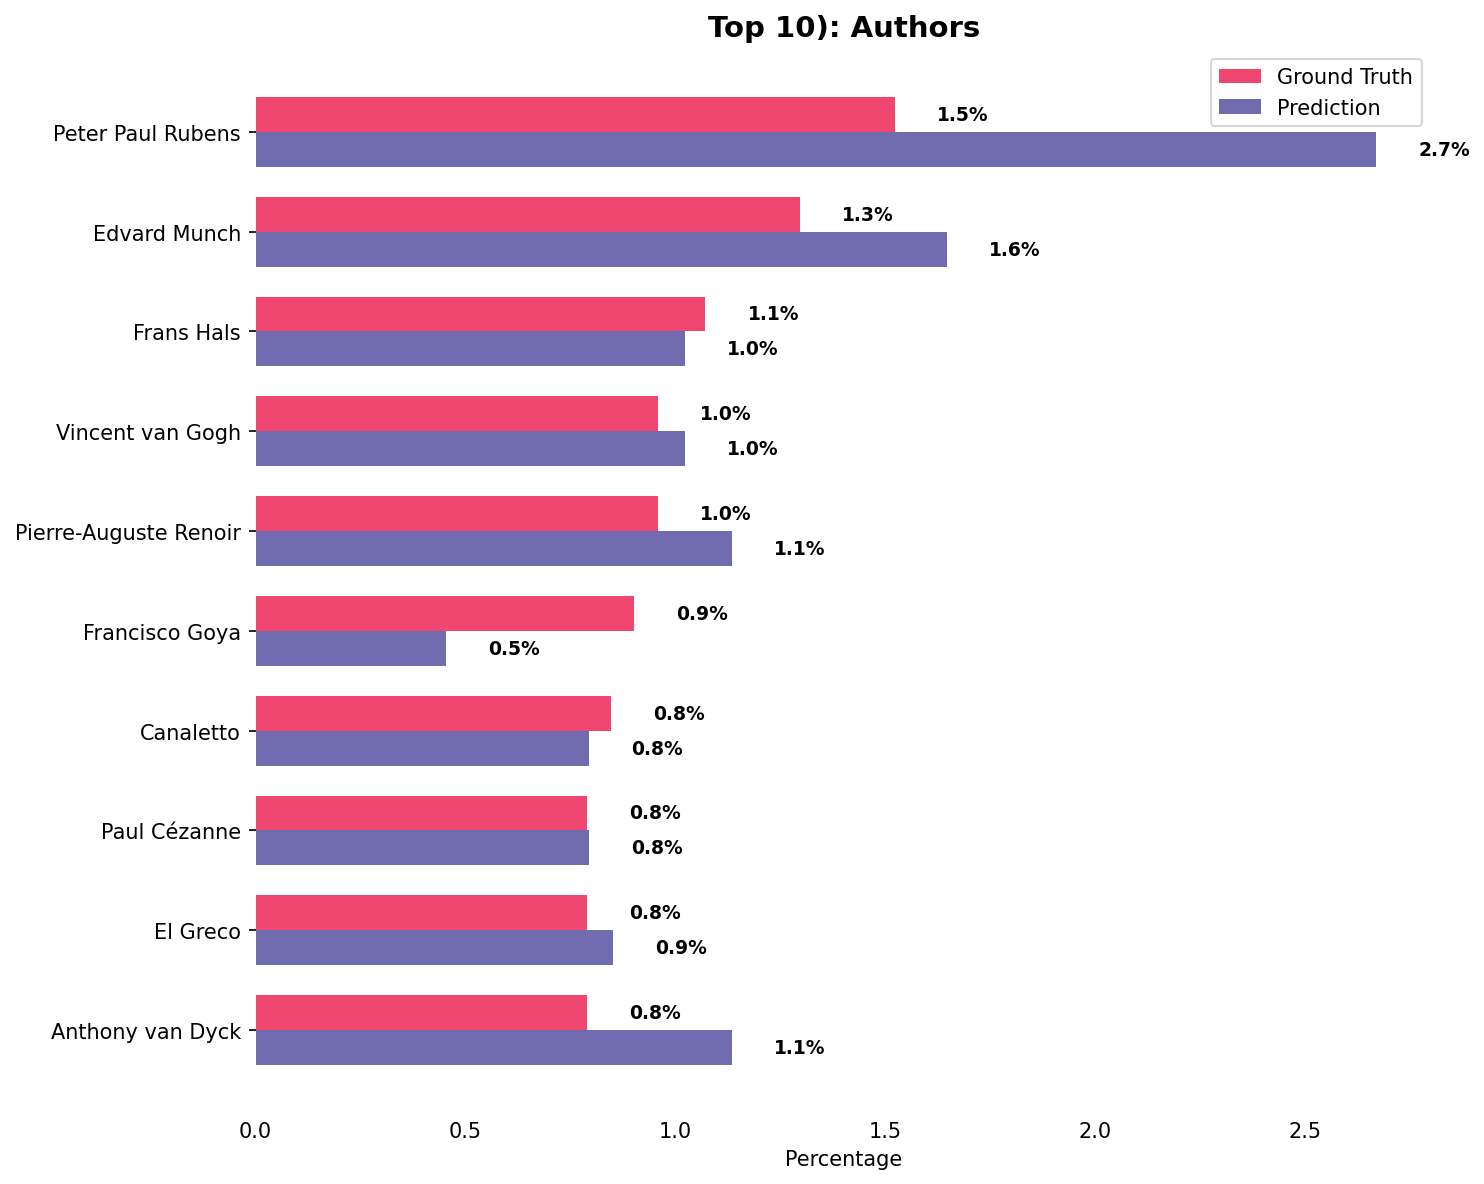

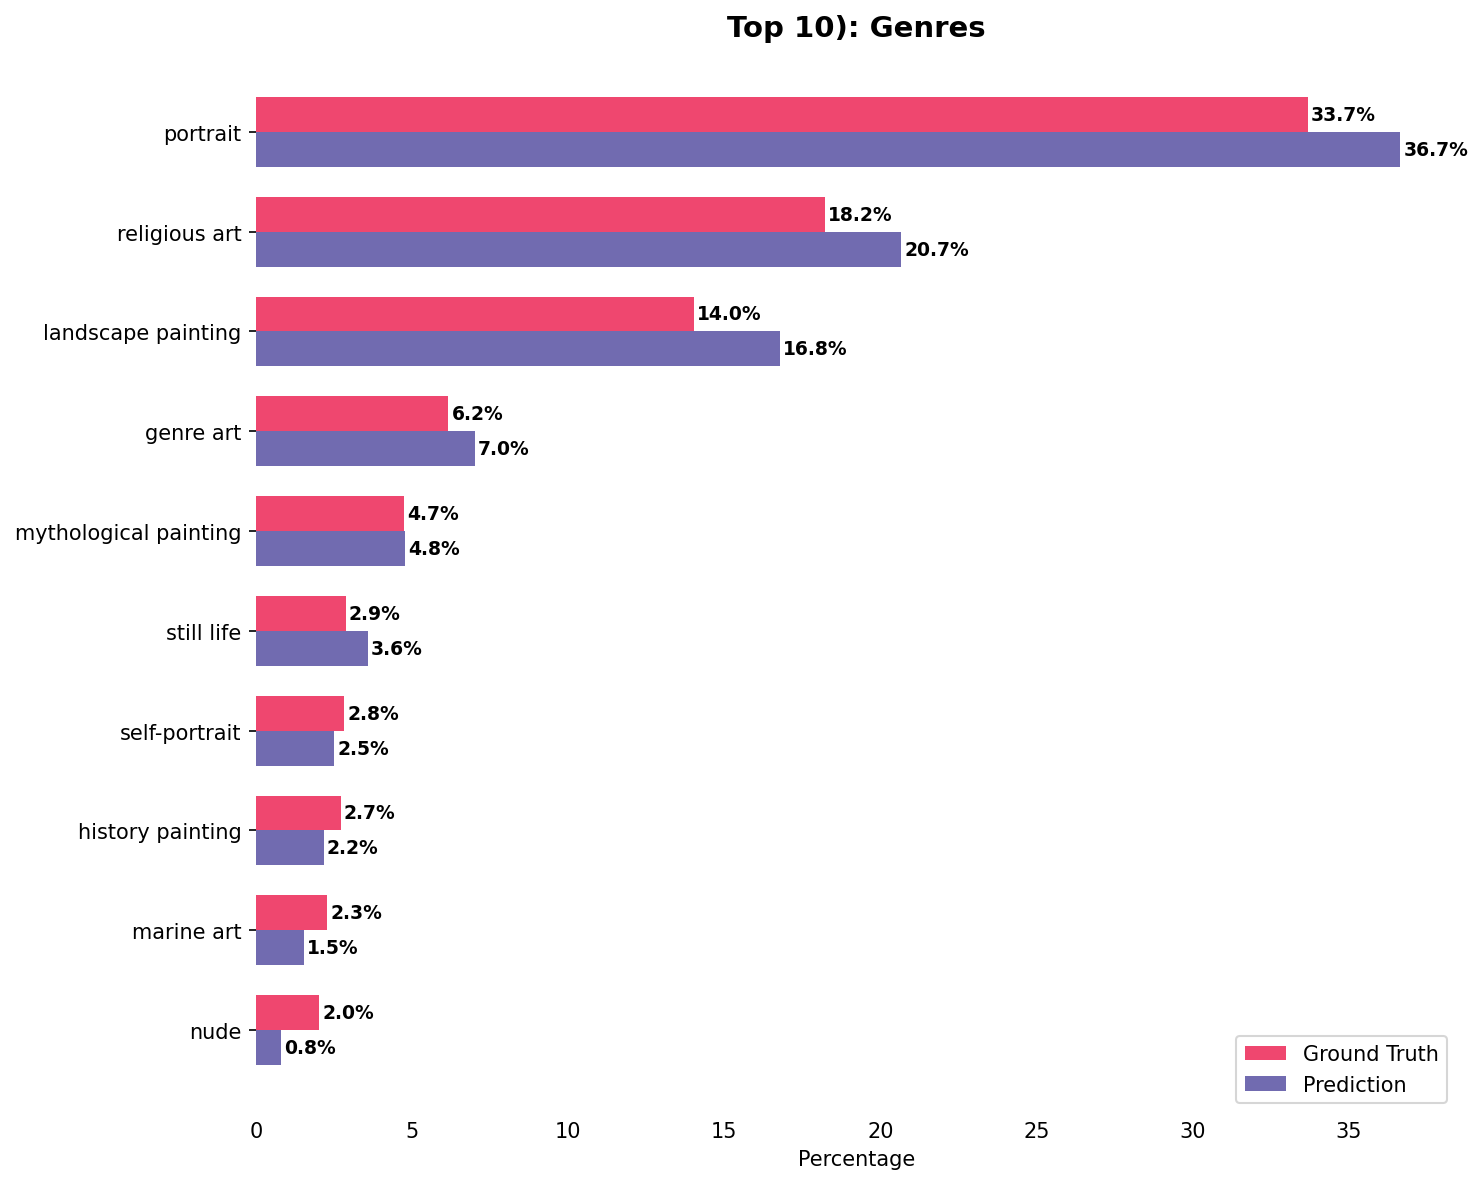

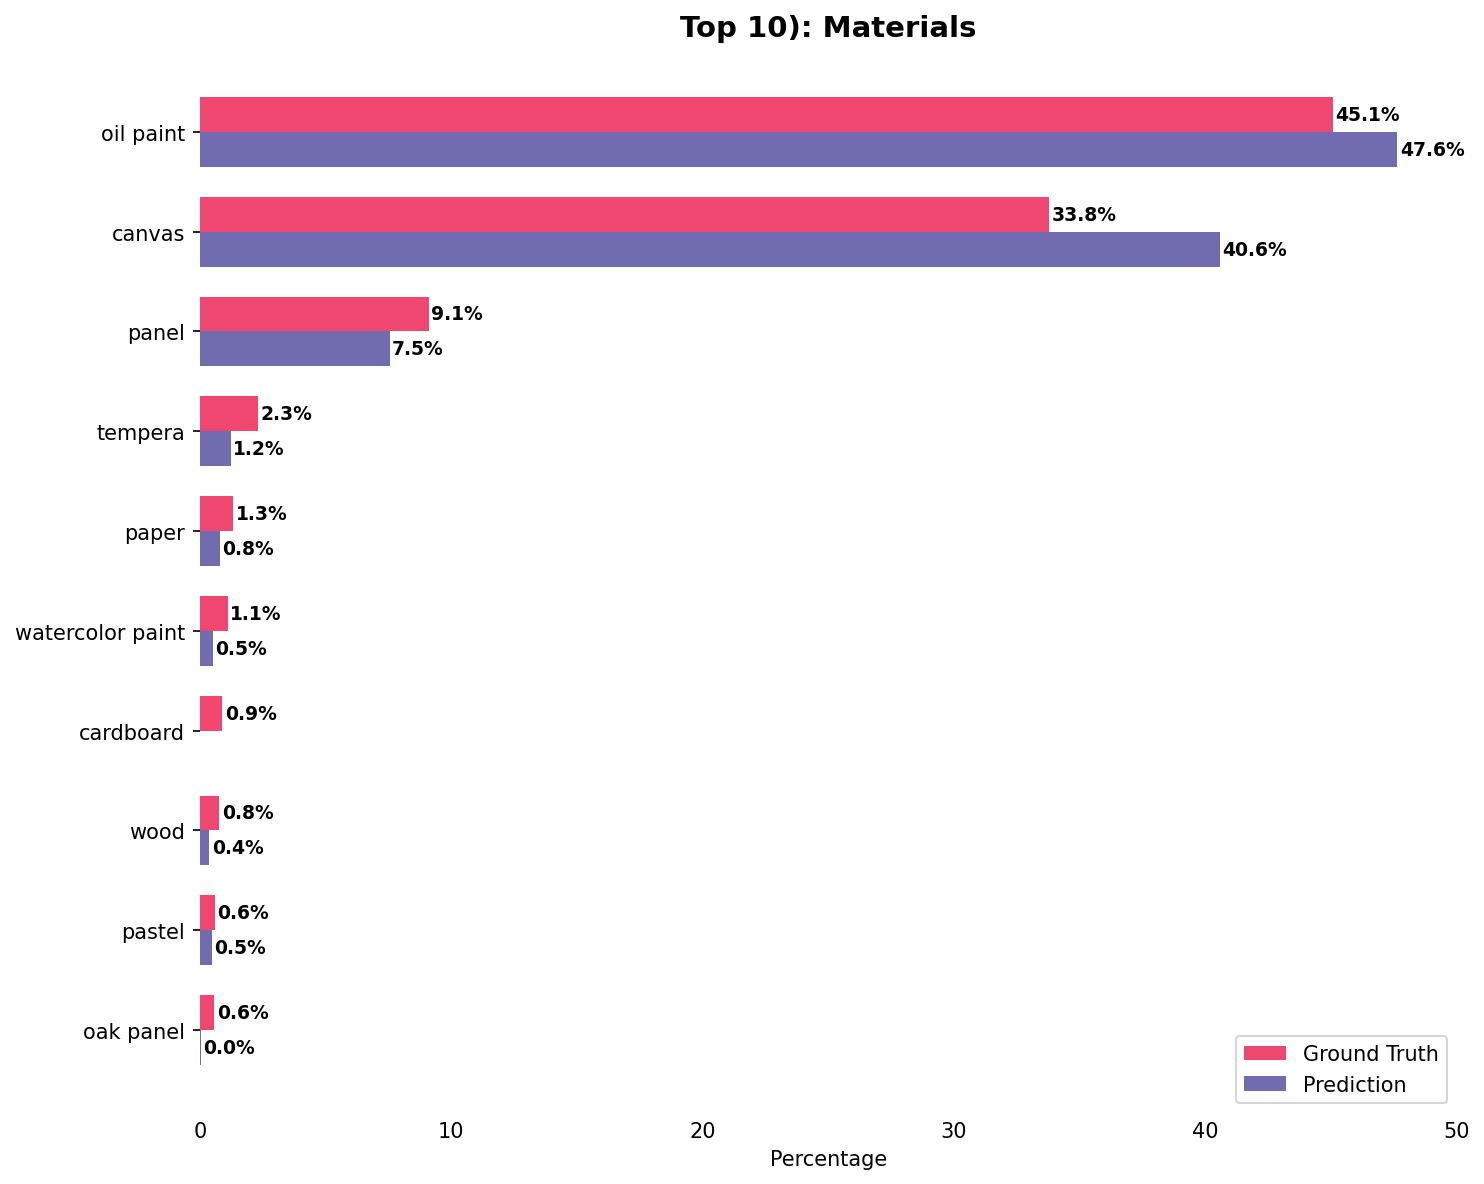

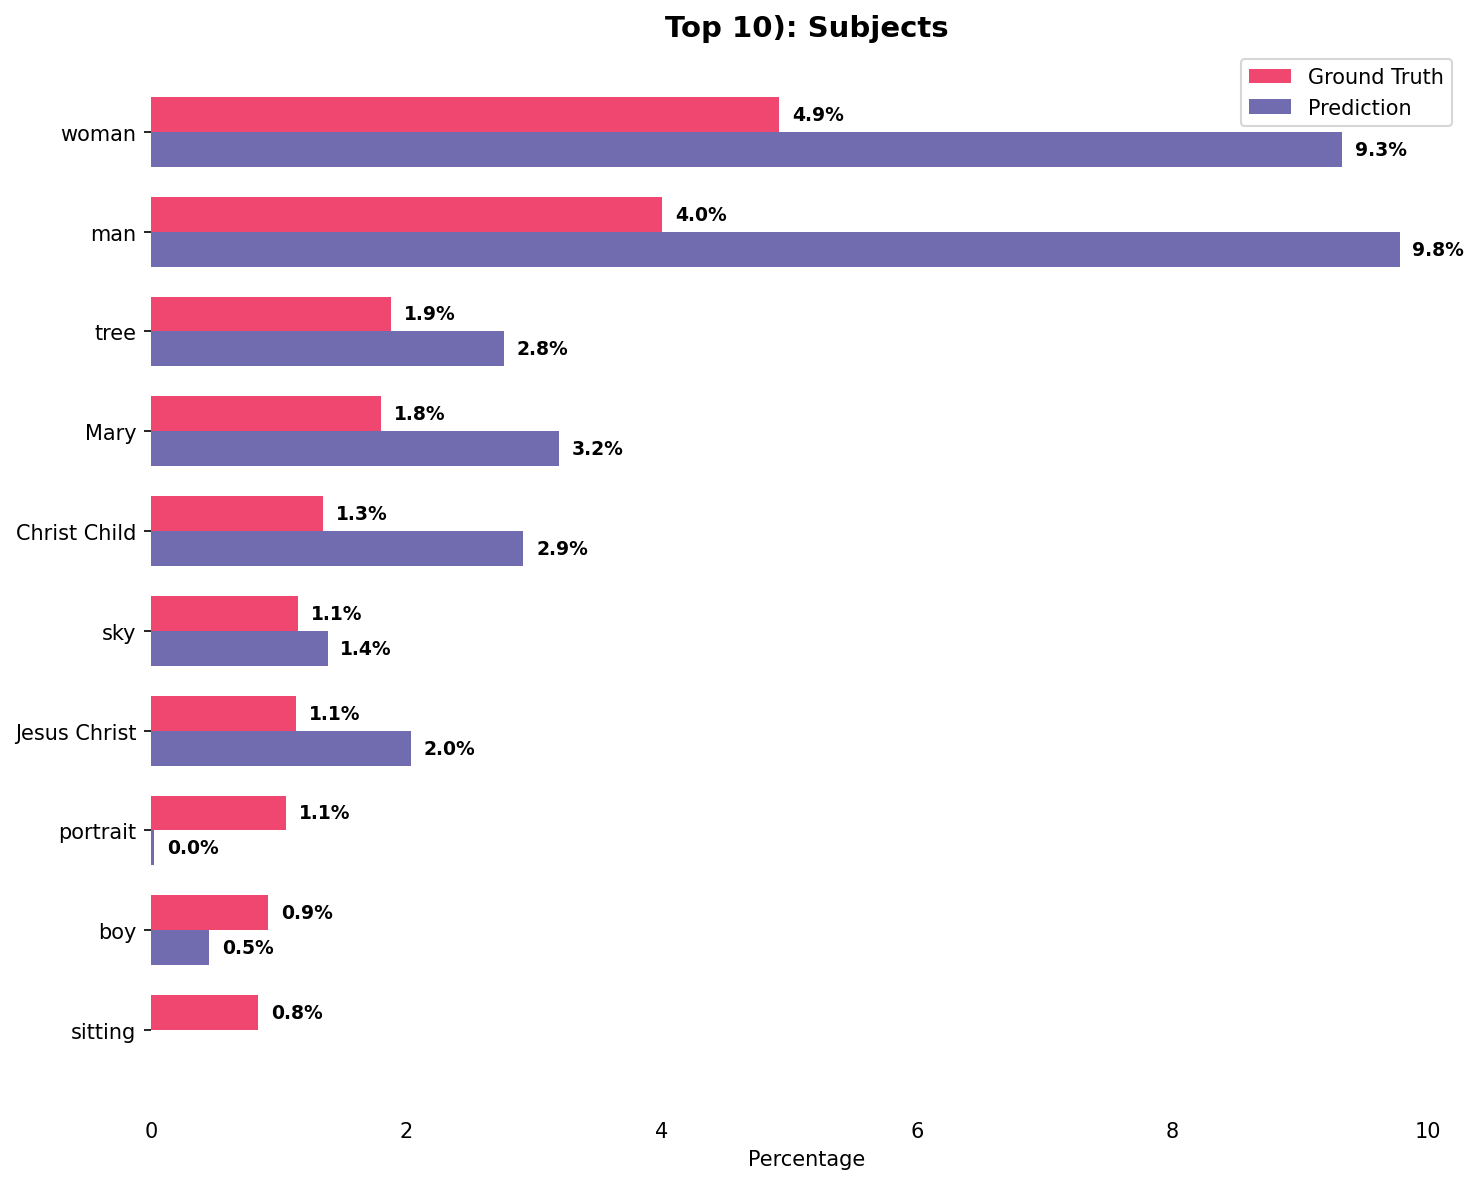

In [ ]:
column_map = {
    'Authors':   {'gt': 'gt_author',   'pred': 'pred_author'},
    'Genres':    {'gt': 'gt_genre',    'pred': 'pred_genre'},
    'Materials': {'gt': 'gt_material', 'pred': 'pred_material'},
    'Subjects':  {'gt': 'gt_subject',  'pred': 'pred_subject'}
}

file_path = "/content/drive/MyDrive/ADSP/TRAIN/Single_Model/1–IMG––4–PROMPT.csv"

try:
    df = pd.read_csv(file_path)

    for col in df.columns:
      esempio = df[col].dropna().iloc[0] if len(df[col].dropna()) > 0 else ""

      if str(esempio).startswith('['):
        df[col] = df[col].apply(normalize_list_column)

    for category, cols in column_map.items():
        counts_gt = get_counts(df, cols['gt'])
        counts_pred = get_counts(df, cols['pred'])

        if counts_gt:
            fig = plot_confronto_relativo(counts_gt, counts_pred, category, top_n=10)
            plt.show()

except FileNotFoundError:
    print(f"Error: File not found.")